# DMS-Messdaten-Auswertung – rotierende Welle

**Zweck.** Auswertung von Zeitreihen eines Dehnungsmessstreifens (DMS) auf einer rotierenden,
biegebelasteten Welle: Kenngrößen im Zeit- und Frequenzbereich, Drehzahlverlauf und der
quantitative Vergleich mit der Balkentheorie.

## Aufbau des Notebooks

| Abschnitt | Inhalt |
|---|---|
| 1 | Setup: Bibliotheken, Plot-Stil, Algorithmus-Konstanten |
| 2 | **Datenimport** – Format, Spalten und Zeiteinheit werden automatisch erkannt |
| 3 | **Datensatz-Überblick** – Umfang, Abtastrate, Lücken, Gesamtverlauf |
| 4 | **Konfiguration** – nur das, was wirklich vom Anwender kommen muss |
| 5 | **Analysefenster** – Auswahl und visuelle Kontrolle |
| 6 | **Signalanalyse** – Zeitbereich, Spektrum, Harmonischen-Fit, Signalqualität |
| 7 | **Ergebnisse** – kompakte Konsolenausgabe |
| 8 | **Visualisierung** – Fit, Spektrum, Residuum |
| 9 | **Drehzahlanalyse** – Ursache der unrealistischen Drehzahlen, robustes Verfahren, automatische Betriebspunkt-Erkennung |
| Teil 2 | **Theorie ↔ Experiment** – Balkentheorie, Unsicherheitsbudget beider Seiten, Bewertung |
| | **Übertragungsqualität**, **Diskussion**, **Export**, **Anhang A–C** (Parameter, Anpassung, Änderungen) |

## Bedienung

1. In Abschnitt 2 `DATA_FILE` setzen (oder `None` lassen → neueste `dms_rot_*.csv` im Ordner).
2. In Abschnitt 4 das Analysefenster und die Ordnung `rpm_order` prüfen.
3. Zellen von oben nach unten ausführen.

Alles andere – Trennzeichen, Dezimalzeichen, Encoding, Kopfzeile, Zeit- und Wertespalte,
Zeiteinheit, Beschriftung und Einheit – wird aus der Datei abgeleitet.

## Konventionen

* **Bezeichner englisch, Ausgaben deutsch.** Der Code bleibt für Dritte lesbar,
  Bericht und Diagramme bleiben in der Sprache der Arbeit.
* **Keine magischen Zahlen.** Jede Zahl steht als benannte Konstante in Abschnitt 1
  (Algorithmen) bzw. in `Config` / `Experiment` (Anwendungsfall).
* **Trennung der Ebenen.** Import → Vorverarbeitung → Analyse → Darstellung → Export
  sind eigene Funktionen ohne versteckte Seiteneffekte; jede Funktion bekommt ihre
  Eingaben als Argument und gibt ihr Ergebnis zurück.

## Mathematische Grundlagen

* **RMS** (Effektivwert): $y_\mathrm{RMS}=\sqrt{\tfrac1N\sum_i y_i^2}$ – energetischer Mittelwert.
* **Amplitudenspektrum**: diskrete Fourier-Transformation mit Hann-Fenster (gegen Leckeffekte)
  und Korrekturfaktor $2/\sum_i w_i$; die Linienhöhe entspricht damit der echten Sinus-Amplitude.
* **Harmonischen-Fit** (Kern der Auswertung): Least-Squares-Anpassung von

  $$y(t)\;\approx\; c_0 \;+\; c_1\,(t-t_0) \;+\; \sum_{k=1}^{K}\Big[a_k\sin(2\pi k f_0 t)+b_k\cos(2\pi k f_0 t)\Big]$$

  Offset $c_0$, Drift $c_1$ und die Amplituden $A_k=\sqrt{a_k^2+b_k^2}$ folgen daraus direkt.
  Der Fit ist **nicht** an das FFT-Frequenzraster gebunden – bei einem 1-s-Fenster beträgt
  die FFT-Auflösung nur 1 Hz, der Fit liefert $f_0$ trotzdem auf drei Nachkommastellen.
* **Drehzahl**: $n = f_0\cdot 60/\text{Ordnung}$. Der mitrotierende DMS durchläuft bei reiner
  Biegung genau **einmal pro Umdrehung** Zug- und Druckzone → Ordnung 1.
* **SNR**: $\mathrm{SNR}=20\log_{10}\!\big(A_1/\sqrt2\,/\,y_\mathrm{Rausch,RMS}\big)$.
  Der Rauschpegel wird auf zwei Wegen bestimmt (Abschnitt 6) – aus dem Fit-Residuum und
  aus der spektralen Rauschdichte abseits der Harmonischen.
* **THD** (Klirrfaktor): $\mathrm{THD}=\sqrt{\sum_{k\ge2}A_k^2}\,/\,A_1$ – Maß dafür, wie rein
  sinusförmig das Signal ist.

## 1 Setup

Bibliotheken, ein einheitlicher Plot-Stil und alle Algorithmus-Konstanten an einer Stelle.
Diese Konstanten sind bewusst **keine** Anwender-Konfiguration: sie beschreiben das Verfahren,
nicht den Versuch, und müssen für eine normale Auswertung nicht angefasst werden.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import NamedTuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy import signal as spsig
from scipy.ndimage import median_filter
from scipy.stats import median_abs_deviation

try:                                    # hübsche Tabellen im Notebook, Fallback beim Skriptlauf
    from IPython.display import display
except ImportError:                     # pragma: no cover
    display = print

# --- einheitlicher Plot-Stil für alle Abbildungen ---------------------------
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.framealpha": 0.9,
})
COLOR_SIGNAL = "#25507b"    # Messsignal
COLOR_MODEL = "#c0392b"     # Modell / Theorie
COLOR_MARK = "#e69f00"      # Markierungen, Sollbereiche
COLOR_MUTED = "#9aa5b1"     # Nebeninformation

# ===========================================================================
#  ALGORITHMUS-KONSTANTEN  (Verfahren, nicht Versuch)
# ===========================================================================

# --- Formaterkennung ---
SNIFF_LINES = 30            # so viele Datenzeilen genügen, um Format und Spalten zu erkennen
COMMENT_CHAR = "#"          # Kommentarzeilen in Messdateien
ENCODING_CANDIDATES = ("utf-8-sig", "utf-8", "cp1252", "latin-1")
# Reihenfolge = Vorrang bei Gleichstand: (Trennzeichen, Dezimalzeichen)
DIALECT_CANDIDATES = ((",", "."), (";", ","), (";", "."), ("\t", "."), ("\t", ","),
                      ("|", "."), (" ", "."))

# --- Zeitachse ---
GAP_FACTOR = 1.8            # dt > GAP_FACTOR*median(dt) => Sprung in der Zeitachse.
                            # 1.8 statt 2.0, damit auch ein einzelnes fehlendes Sample
                            # erkannt wird, ohne auf normalen Jitter anzuspringen.
MAX_BLOCK_STEP = 10.0       # Sprünge bis zu dieser Sample-Zahl gehören zur paketweisen
                            # Zeitrekonstruktion (Artefakt), größere sind echte Ausfälle.
MIN_BLOCKS_FOR_REPAIR = 5   # unter so wenigen Blöcken ist das Muster kein Systemfehler

# --- Spektrum und Fit ---
FREQ_SEARCH_MIN_HZ = 0.5    # untere Suchgrenze: blendet DC und Drift aus
N_HARMONICS = 5             # Grundwelle + 4 Oberwellen; darüber liegt hier nur noch Rauschen
REFINE_BAND_BINS = 1.5      # Suchbreite der Feinabstimmung in FFT-Bins um das grobe Maximum
REFINE_GRID = 101           # Stützstellen darin; 101 => Auflösung ~ Bin/34
NOISE_EXCLUDE_BINS = 3      # Bins um jede Harmonische, die nicht zum Rauschen zählen
NOISE_EXCLUDE_REL = 0.10    # ... mindestens aber 10 % von f0 (fängt Seitenbänder ein)
NOISE_EXCLUDE_DC_REL = 0.5  # Bins unterhalb 0.5·f0 zählen nicht zum Rauschen: dort stehen
                            # Drift und die Fensterflanke der Grundwelle, kein Messrauschen.
OUTLIER_MAD_K = 6.0         # Ausreißer: |Residuum - Median| > k * robuste Streuung (MAD)
MIN_PERIODS_PER_PART = 5    # Mindestlänge eines Teilfensters der Stationaritätsprüfung
MAX_STATIONARITY_PARTS = 8  # mehr Teilfenster bringen keine zusätzliche Aussage
STATIONARITY_TOL = 0.01     # bis 1 % Frequenzstreuung gilt ein Fenster als stationär
                            # (gemessen: stationäre Fenster 0.1-0.9 %, Hochlauf > 2 %)

# --- Drehzahlermittlung ---
SPEED_LP_HARMONICS = 8.0    # Tiefpass bei 8*f0: hält die Kurvenform, entfernt das Breitbandrauschen
SPEED_LP_MAX_NYQUIST = 0.4  # Sicherheitsgrenze für die Grenzfrequenz (Anteil von fs/2)
SPEED_FILTER_ORDER = 4      # Butterworth 4. Ordnung, nullphasig (filtfilt)
SPEED_HYSTERESIS_FRAC = 0.25  # Schmitt-Trigger: erst nach -0.25*A gilt der nächste
                              # Nulldurchgang als echt -> Rauschen kann keine Perioden erzeugen
SPEED_PLAUSIBLE_FACTOR = 5.0  # Plausibilitätsband um die mittlere Drehfrequenz (Faktor)
SPEED_MEDIAN_WINDOW = 9       # Perioden im gleitenden Median der Ausreißerprüfung. Der Vergleich
                              # erfolgt lokal, damit ein Drehzahl-Hochlauf nicht als Ausreißer gilt.
SPEED_OUTLIER_MAD_K = 5.0     # Abweichung vom lokalen Median in robusten Streuungen (MAD)
SEGMENT_TOL = 0.03          # Betriebspunkt-Erkennung: 3 % Drehzahlband
SEGMENT_MIN_S = 1.0         # kürzere Abschnitte sind keine Betriebspunkte

# --- Darstellung ---
LOG_PLOT_FLOOR = 1e-6       # untere Klemme für logarithmische Achsen (0 ist dort nicht darstellbar)
PLOT_MAX_POINTS = 1500      # darüber wird der Verlauf als Min/Max-Hüllkurve gezeichnet: eine
                            # Linie aus 40 000 Punkten ist auf Bildbreite nur noch ein Farbblock

## 2 Datenimport

Der Import erkennt selbstständig **Encoding, Trennzeichen, Dezimalzeichen, Kopfzeile,
Zeit- und Wertespalte sowie die Zeiteinheit**. Damit läuft das Notebook ohne Umbau auf
einer deutschen Excel-CSV (`;` / `,`) genauso wie auf den Dateien des UDP-Servers.

Erkennungsstrategie in Kurzform:

* **Encoding** – die Kandidatenliste wird der Reihe nach probiert, das erste dekodierbare gewinnt.
* **Trennzeichen + Dezimalzeichen gemeinsam** – für jedes Paar wird gezählt, wie viele Felder
  sich als Zahl lesen lassen. Das ist zuverlässiger als `csv.Sniffer`, den ein Dezimalkomma
  regelmäßig zu einem Komma-Trennzeichen verleitet.
* **Kopfzeile** – vorhanden, wenn die erste Zeile nicht vollständig numerisch ist.
* **Spaltenrollen** – über Namensmuster (`t_ms`, `time`, `microstrain`, …), ersatzweise über
  die Struktur: monoton steigende Spalte = Zeit, letzte numerische Spalte = Messwert.
* **Zeiteinheit** – aus dem Spaltennamen (`t_ms`, `t_us`, `t_s`).

Jede Erkennung lässt sich per Argument überschreiben, z. B.
`read_timeseries(path, value_col="code", time_unit="s")`.

In [2]:
# ===========================================================================
#  2.1  Formaterkennung
# ===========================================================================
class FileFormat(NamedTuple):
    """Ergebnis der Formaterkennung einer Textdatei."""
    encoding: str
    delimiter: str
    decimal: str
    has_header: bool


def _is_number(field: str, decimal: str) -> bool:
    """True, wenn sich das Feld mit dem angegebenen Dezimalzeichen als Zahl lesen lässt."""
    text = field.strip().strip('"')
    if not text:
        return False
    if decimal != ".":
        text = text.replace(decimal, ".")
    try:
        float(text)
    except ValueError:
        return False
    return True


def _read_sample(path: Path) -> tuple[str, list[str]]:
    """Encoding bestimmen und die ersten Nutzzeilen lesen (ohne Kommentare/Leerzeilen)."""
    for encoding in ENCODING_CANDIDATES:
        try:
            with open(path, "r", encoding=encoding) as handle:
                lines: list[str] = []
                for raw in handle:
                    text = raw.strip()
                    if text and not text.startswith(COMMENT_CHAR):
                        lines.append(text)
                    if len(lines) >= SNIFF_LINES:
                        break
        except UnicodeDecodeError:
            continue
        if lines:
            return encoding, lines
        raise ValueError(f"Datei enthält keine Datenzeilen: {path}")
    raise ValueError(f"Encoding nicht erkannt, probiert: {ENCODING_CANDIDATES}")


def _numeric_score(lines: list[str], delimiter: str, decimal: str) -> tuple[float, int]:
    """Bewertet ein (Trennzeichen, Dezimalzeichen)-Paar: Anteil lesbarer Zahlen und Spaltenzahl.

    Nur Paare mit über alle Zeilen konstanter Spaltenzahl kommen in Frage - eine falsche
    Wahl zerlegt die Zeilen unterschiedlich und fällt damit sofort durch.
    """
    widths = {line.count(delimiter) for line in lines}
    if len(widths) != 1:
        return 0.0, 0
    n_sep = widths.pop()
    if n_sep == 0:
        return 0.0, 0
    rows = [line.split(delimiter) for line in lines]
    data_rows = rows[1:] if len(rows) > 1 else rows      # erste Zeile kann Kopfzeile sein
    fields = [f for row in data_rows for f in row]
    if not fields:
        return 0.0, 0
    numeric = sum(_is_number(f, decimal) for f in fields)
    return numeric / len(fields), n_sep + 1


def detect_format(path: Path) -> FileFormat:
    """Encoding, Trennzeichen, Dezimalzeichen und Kopfzeile einer Textdatei bestimmen."""
    encoding, lines = _read_sample(path)
    best, best_key = None, (0.0, 0)
    for delimiter, decimal in DIALECT_CANDIDATES:
        score, n_cols = _numeric_score(lines, delimiter, decimal)
        if (score, n_cols) > best_key:      # strikt größer => bei Gleichstand gewinnt die Reihenfolge
            best, best_key = (delimiter, decimal), (score, n_cols)
    if best is None or best_key[0] == 0.0:
        raise ValueError(f"Spaltenformat nicht erkannt: {path}")
    delimiter, decimal = best
    header = not all(_is_number(f, decimal) for f in lines[0].split(delimiter))
    return FileFormat(encoding, delimiter, decimal, header)

In [3]:
# ===========================================================================
#  2.2  Spaltenrollen, Zeiteinheit und Beschriftung
# ===========================================================================
# Namensmuster -> Rolle. Reihenfolge = Priorität.
TIME_HINTS = ("t_ms", "t_us", "t_s", "time", "zeit", "timestamp", "t")
VALUE_HINTS = ("microstrain", "mikrostrain", "strain", "dehnung", "eps", "value", "wert", "y")
TIME_UNIT_HINTS = {"_us": "us", "_ms": "ms", "_s": "s", "[us]": "us", "[ms]": "ms", "[s]": "s"}
TIME_UNIT_SCALE = {"us": 1e-6, "ms": 1e-3, "s": 1.0}
# Bekannte Messgrößen -> (Beschriftung, Einheit) für Achsen und Berichte
SIGNAL_LABELS = {
    "microstrain": ("Dehnung", "µε"),
    "strain": ("Dehnung", "µε"),
    "dehnung": ("Dehnung", "µε"),
    "code": ("ADC-Code", "LSB"),
}


def _match_hint(name: str, hints) -> bool:
    key = name.strip().lower()
    return any(key == h or key.startswith(h) for h in hints)


def _pick_columns(frame: pd.DataFrame) -> tuple[str, str]:
    """Zeit- und Wertespalte bestimmen: erst über Namensmuster, sonst über die Struktur."""
    names = list(frame.columns)
    numeric = [c for c in names if pd.to_numeric(frame[c], errors="coerce").notna().any()]
    if len(numeric) < 2:
        raise ValueError(f"Mindestens zwei numerische Spalten nötig, gefunden: {numeric}")

    time_col = next((c for c in numeric if _match_hint(str(c), TIME_HINTS)), None)
    if time_col is None:        # Struktur-Fallback: die Zeit ist die einzige monoton steigende Spalte
        time_col = next((c for c in numeric
                         if pd.to_numeric(frame[c], errors="coerce").is_monotonic_increasing), numeric[0])

    rest = [c for c in numeric if c != time_col]
    value_col = next((c for c in rest if _match_hint(str(c), VALUE_HINTS)), rest[-1])
    return time_col, value_col


def _detect_time_unit(column_name: str) -> str | None:
    """Zeiteinheit aus dem Spaltennamen ableiten (t_ms, t_us, time[s], ...)."""
    key = str(column_name).strip().lower()
    for suffix, unit in TIME_UNIT_HINTS.items():
        if key.endswith(suffix):
            return unit
    return None


def _signal_labels(column_name: str) -> tuple[str, str]:
    """Beschriftung und Einheit zur Wertespalte; unbekannte Spalten behalten ihren Namen."""
    return SIGNAL_LABELS.get(str(column_name).strip().lower(), (str(column_name), ""))

In [4]:
# ===========================================================================
#  2.3  Zeitachse prüfen und reparieren
# ===========================================================================
class TimelineInfo(NamedTuple):
    """Zustand der Zeitachse: reguläre Sprünge (Paketgrenzen) vs. echte Ausfälle."""
    dt_nominal: float       # Median-Abtastintervall, wie es in der Datei steht
    n_blocks: int           # Anzahl regulärer Sprünge = Übertragungsblöcke
    block_len: float        # Samples je Block (Median)
    n_dropouts: int         # Sprünge, die für einen Übertragungsblock zu groß sind
    rate_true: float        # tatsächliche Abtastrate aus den Blockgrenzen [Hz]
    repaired: bool


def _timeline_breaks(t: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """Sprünge in der Zeitachse klassifizieren: Blockgrenze (klein, regelmäßig) vs. Ausfall."""
    dt = np.diff(t)
    dt_nominal = float(np.median(dt))
    steps = dt / dt_nominal
    is_break = steps > GAP_FACTOR
    is_dropout = steps > MAX_BLOCK_STEP
    return is_break, is_dropout, dt_nominal


def analyse_timeline(t: np.ndarray) -> TimelineInfo:
    """Zeitachse beschreiben, ohne sie zu verändern."""
    is_break, is_dropout, dt_nominal = _timeline_breaks(t)
    n_blocks = int((is_break & ~is_dropout).sum())
    block_len = (float(np.median(np.diff(np.flatnonzero(is_break))))
                 if is_break.sum() > 1 else float("nan"))
    return TimelineInfo(dt_nominal, n_blocks, block_len, int(is_dropout.sum()),
                        1.0 / dt_nominal, repaired=False)


def repair_timeline(t: np.ndarray) -> tuple[np.ndarray, TimelineInfo]:
    """Zeitstempel innerhalb der Übertragungsblöcke gleichmäßig neu verteilen.

    WARUM: Der UDP-Server stempelt nur das *erste* Sample eines Pakets mit der echten
    Uhrzeit des Knotens und interpoliert den Rest mit der *nominellen* Abtastrate aus dem
    Paket-Header. Weicht die echte ADC-Rate davon ab, sammelt sich der Fehler über das
    Paket an und wird an der Paketgrenze in einem Sprung nachgeholt. Das erzeugt

      * eine sägezahnförmige Zeitverzerrung innerhalb jedes Pakets und
      * hunderte scheinbarer "Datenlücken", die keine sind.

    Da die Blockanfänge aus dem Hardware-Timer stammen und damit belastbar sind, lässt sich
    die Zeitachse exakt rekonstruieren: Samples eines Blocks werden linear zwischen zwei
    Blockanfängen verteilt. Echte Ausfälle bleiben als Lücke erhalten.
    """
    base = analyse_timeline(t)
    is_break, is_dropout, dt_nominal = _timeline_breaks(t)
    if base.n_blocks < MIN_BLOCKS_FOR_REPAIR:
        return t.copy(), base

    starts = np.r_[0, np.flatnonzero(is_break) + 1, len(t)]
    dropout_at = set((np.flatnonzero(is_dropout) + 1).tolist())
    repaired = t.copy()
    rates: list[float] = []
    for begin, end in zip(starts[:-1], starts[1:]):
        n = end - begin
        if n < 2:
            continue
        if end < len(t) and end not in dropout_at:
            # Blockanfänge sind echte Zeitstempel -> dazwischen gleichmäßig verteilen
            repaired[begin:end] = np.linspace(t[begin], t[end], n, endpoint=False)
            rates.append(n / (t[end] - t[begin]))
        else:
            # Block endet an einem Ausfall oder am Dateiende: lokale Rate fortschreiben
            rate = float(np.median(rates[-20:])) if rates else 1.0 / dt_nominal
            repaired[begin:end] = t[begin] + np.arange(n) / rate
    return repaired, base._replace(rate_true=float(np.median(rates)), repaired=True)


def dropout_mask(t: np.ndarray, info: "ImportInfo") -> np.ndarray:
    """Maske über np.diff(t): True, wo ein echter Übertragungsausfall liegt.

    Einzige Stelle, an der 'echter Ausfall' definiert wird - Überblick, Diagramme,
    Drehzahlanalyse und Verlustbilanz greifen alle hierauf zu.
    """
    return np.diff(t) > MAX_BLOCK_STEP * info.timeline.dt_nominal


def dropout_spans(t: np.ndarray, info: "ImportInfo"):
    """Ausfälle als (Beginn, Ende)-Paare in Sekunden."""
    mask = dropout_mask(t, info)
    return list(zip(t[:-1][mask], t[1:][mask]))


def dropout_events(frame: pd.DataFrame, info: "ImportInfo") -> pd.DataFrame:
    """Echte Übertragungsausfälle mit Zeitpunkt, Dauer und fehlender Sample-Zahl.

    Die Sample-Zahl wird mit der *tatsächlichen* Abtastrate gerechnet; mit dem
    nominellen Wert läge sie systematisch daneben.
    """
    t = frame["t"].to_numpy()
    mask = dropout_mask(t, info)
    return pd.DataFrame({
        "t_start [s]": t[:-1][mask],
        "Dauer [s]": np.diff(t)[mask],
        "fehlende Samples": np.round(np.diff(t)[mask] * info.timeline.rate_true - 1).astype(int),
    })

In [5]:
# ===========================================================================
#  2.4  Einlesen
# ===========================================================================
@dataclass(frozen=True)
class ImportInfo:
    """Alles, was beim Einlesen über die Datei gelernt wurde."""
    path: Path
    fmt: FileFormat
    time_col: str
    value_col: str
    time_unit: str
    time_unit_detected: bool    # False = aus dem Spaltennamen nicht ableitbar, "s" angenommen
    label: str
    unit: str
    n_rows_raw: int
    n_dropped_invalid: int
    n_dropped_duplicate: int
    timeline: TimelineInfo


def newest_measurement(folder: Path = Path("."), pattern: str = "dms_rot_*.csv") -> Path:
    """Neueste Messdatei im Ordner - praktisch für 'einfach die letzte Messung auswerten'."""
    files = sorted(folder.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f"Keine Datei zu '{pattern}' in {folder.resolve()}")
    return files[-1]


def read_timeseries(path, *, time_col=None, value_col=None, time_unit=None,
                    fmt=None, repair=True) -> tuple[pd.DataFrame, ImportInfo]:
    """Messdatei einlesen und als DataFrame mit den Spalten `t` [s] und `y` liefern.

    Alle Format- und Spaltenangaben sind optional; ohne Angabe werden sie erkannt.
    Rückgabe: (DataFrame, ImportInfo) - die Info trägt jede getroffene Annahme mit,
    damit die Auswertung nachvollziehbar bleibt.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Datei nicht gefunden: {path.resolve()}")

    fmt = fmt or detect_format(path)
    raw = pd.read_csv(path, sep=fmt.delimiter, decimal=fmt.decimal, comment=COMMENT_CHAR,
                      encoding=fmt.encoding, header=0 if fmt.has_header else None,
                      engine="python", skip_blank_lines=True)
    if not fmt.has_header:
        raw.columns = [f"col{i}" for i in range(raw.shape[1])]

    detected_time, detected_value = _pick_columns(raw)
    time_col = time_col if time_col is not None else detected_time
    value_col = value_col if value_col is not None else detected_value
    for column in (time_col, value_col):
        if column not in raw.columns:
            raise KeyError(f"Spalte '{column}' fehlt. Vorhanden: {list(raw.columns)}")

    detected_unit = time_unit or _detect_time_unit(time_col)
    unit = detected_unit or "s"     # ohne Hinweis im Spaltennamen bleibt nur die Annahme
    if unit not in TIME_UNIT_SCALE:
        raise ValueError(f"Zeiteinheit '{unit}' unbekannt, erlaubt: {sorted(TIME_UNIT_SCALE)}")

    frame = pd.DataFrame({
        "t": pd.to_numeric(raw[time_col], errors="coerce") * TIME_UNIT_SCALE[unit],
        "y": pd.to_numeric(raw[value_col], errors="coerce"),
    })
    n_raw = len(frame)
    frame = frame.dropna()
    n_invalid = n_raw - len(frame)
    frame = frame.sort_values("t").drop_duplicates(subset="t").reset_index(drop=True)
    n_duplicate = n_raw - n_invalid - len(frame)
    if len(frame) < 2:
        raise ValueError("Zu wenige gültige Datenpunkte nach dem Einlesen.")

    t = frame["t"].to_numpy()
    if repair:
        t, timeline = repair_timeline(t)
        frame["t"] = t
    else:
        timeline = analyse_timeline(t)

    label, value_unit = _signal_labels(value_col)
    info = ImportInfo(path, fmt, str(time_col), str(value_col), unit, detected_unit is not None,
                      label, value_unit, n_raw, n_invalid, n_duplicate, timeline)
    return frame, info

In [6]:
# --- Datenquelle: die einzige Pflichtangabe des Imports ---------------------
DATA_FILE = "dms_rot_20260723_153829.csv"   # None => neueste dms_rot_*.csv im Ordner

data, info = read_timeseries(DATA_FILE or newest_measurement())

print(f"Datei            : {info.path.name}")
print(f"Format erkannt   : Encoding {info.fmt.encoding}, Trennzeichen {info.fmt.delimiter!r}, "
      f"Dezimalzeichen {info.fmt.decimal!r}, Kopfzeile {'ja' if info.fmt.has_header else 'nein'}")
print(f"Spalten erkannt  : Zeit '{info.time_col}' [{info.time_unit}"
      f"{'' if info.time_unit_detected else ', ANGENOMMEN'}] -> t [s], "
      f"Wert '{info.value_col}' -> y [{info.unit}]  ({info.label})")
if not info.time_unit_detected:
    print("  Hinweis: Die Zeiteinheit steht nicht im Spaltennamen und wurde als Sekunden\n"
          "  angenommen. Falls die Datei Millisekunden enthält: "
          "read_timeseries(pfad, time_unit='ms')")

Datei            : dms_rot_20260723_153829.csv
Format erkannt   : Encoding utf-8-sig, Trennzeichen ',', Dezimalzeichen '.', Kopfzeile ja
Spalten erkannt  : Zeit 't_ms' [ms] -> t [s], Wert 'microstrain' -> y [µε]  (Dehnung)


## 3 Datensatz-Überblick

Umfang, Abtastrate, Lücken und Wertebereich – und sofort der komplette Verlauf, damit klar
ist, womit man es zu tun hat, bevor irgendein Fenster ausgewählt wird.

### Warum hier zwei Abtastraten stehen

Die Zeitstempel des UDP-Servers werden paketweise erzeugt (siehe `repair_timeline`).
Deshalb werden getrennt ausgewiesen:

* **nominell** – die Rate, mit der die Datei ihre Zeitstempel gebildet hat (Header-Wert `sps`),
* **tatsächlich** – die aus den Blockgrenzen rekonstruierte reale Rate des ADC.

Weichen beide voneinander ab, ist das kein Auswertefehler, sondern die Toleranz des internen
ADS1220-Oszillators. Für alle Frequenz- und Drehzahlangaben zählt die tatsächliche Rate.

=== Datensatz-Überblick ===
                       Kenngröße              Wert Einheit
                     Datenpunkte             42793        
   verworfen: ungültig / doppelt             0 / 0        
                       Messdauer             46.01       s
Abtastrate (nominell laut Datei)              1000      Hz
        Abtastrate (tatsächlich)             979.6      Hz
              Übertragungsblöcke 429 à ~99 Samples        
         Zeitachse rekonstruiert                ja        
                  echte Ausfälle                 2        
          dabei fehlende Samples     2278 (5.05 %)        
              Ausfallzeit gesamt             2.327       s
                    Wertebereich  -175.92 … 179.59      µε
             Mittelwert / Median      1.53 / -0.44      µε

=== Vorschau ===


,t,y
0,0.000000,82.50
1,0.001021,70.36
2,0.002042,83.29
3,0.003062,70.86
4,0.004083,55.95


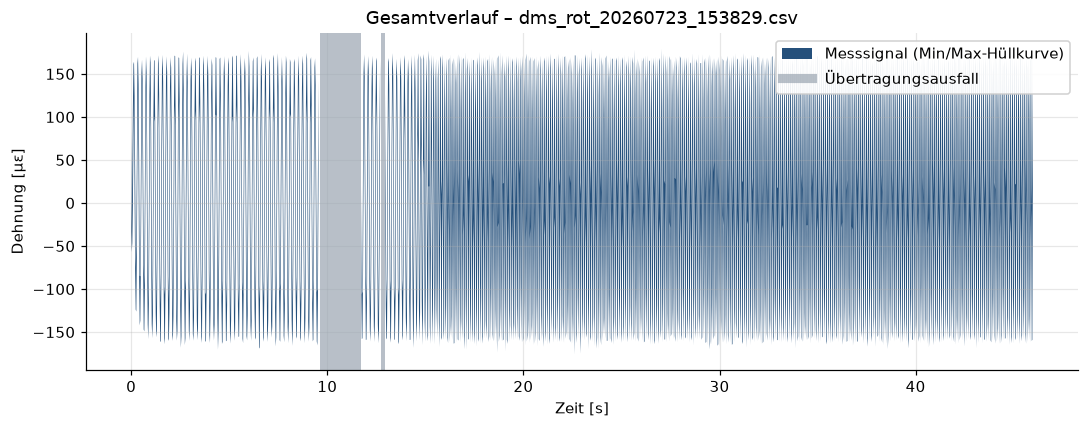

In [7]:
# ===========================================================================
#  3  Überblick
# ===========================================================================
def describe_dataset(frame: pd.DataFrame, info: ImportInfo) -> pd.DataFrame:
    """Kennzahlen des gesamten Datensatzes als Tabelle (auch für den Export brauchbar)."""
    t, y = frame["t"].to_numpy(), frame["y"].to_numpy()
    tl = info.timeline
    duration = float(t[-1] - t[0])
    events = dropout_events(frame, info)
    lost = int(events["fehlende Samples"].sum())
    rows = [
        ("Datenpunkte", len(frame), ""),
        ("verworfen: ungültig / doppelt", f"{info.n_dropped_invalid} / {info.n_dropped_duplicate}", ""),
        ("Messdauer", duration, "s"),
        ("Abtastrate (nominell laut Datei)", 1.0 / tl.dt_nominal, "Hz"),
        ("Abtastrate (tatsächlich)", tl.rate_true, "Hz"),
        ("Übertragungsblöcke", f"{tl.n_blocks} à ~{tl.block_len:.0f} Samples"
         if tl.n_blocks else "keine (gleichmäßige Zeitachse)", ""),
        ("Zeitachse rekonstruiert", "ja" if tl.repaired else "nein", ""),
        ("echte Ausfälle", len(events), ""),
        ("dabei fehlende Samples", f"{lost} ({100*lost/max(len(frame)+lost, 1):.2f} %)", ""),
        ("Ausfallzeit gesamt", float(events["Dauer [s]"].sum()), "s"),
        ("Wertebereich", f"{y.min():.2f} … {y.max():.2f}", info.unit),
        ("Mittelwert / Median", f"{y.mean():.2f} / {np.median(y):.2f}", info.unit),
    ]
    table = pd.DataFrame(rows, columns=["Kenngröße", "Wert", "Einheit"])
    table["Wert"] = [f"{v:.4g}" if isinstance(v, float) else str(v) for v in table["Wert"]]
    return table


def _minmax_envelope(t: np.ndarray, y: np.ndarray, spans, n_buckets: int = PLOT_MAX_POINTS):
    """Min/Max je Zeitabschnitt: zeigt den Amplitudenverlauf langer Aufzeichnungen ehrlich.

    Ausfälle werden auf NaN gesetzt, damit die Hüllkurve keine Lücke überbrückt und dort
    eine Schwingung vortäuscht, die nicht gemessen wurde.
    """
    starts = np.unique(np.linspace(0, len(t), n_buckets + 1)[:-1].astype(int))
    t_bucket = t[starts]
    t_bucket_end = np.r_[t_bucket[1:], t[-1]]
    low = np.minimum.reduceat(y, starts).astype(float)
    high = np.maximum.reduceat(y, starts).astype(float)
    for start, end in spans:
        # Abschnitte werden über Indizes gebildet - ein Abschnitt, der einen Ausfall enthält,
        # deckt zeitlich sehr viel mehr ab als seine Nachbarn. Überlappungstest statt Punkttest.
        overlaps = (t_bucket < end) & (t_bucket_end > start)
        low[overlaps], high[overlaps] = np.nan, np.nan
    return t_bucket, low, high


def plot_signal(frame: pd.DataFrame, info: ImportInfo, window=None, title=None, ax=None):
    """Signalverlauf zeichnen; `window` hebt den Analysebereich hervor.

    Eine Funktion für Gesamtverlauf und Fensterkontrolle - dieselbe Darstellung,
    damit beide Abbildungen vergleichbar bleiben.
    """
    if ax is None:
        _, ax = plt.subplots()
    t, y = frame["t"].to_numpy(), frame["y"].to_numpy()
    spans = dropout_spans(t, info)

    if len(t) > PLOT_MAX_POINTS:
        t_bucket, low, high = _minmax_envelope(t, y, spans)
        ax.fill_between(t_bucket, low, high, color=COLOR_SIGNAL, lw=0,
                        label="Messsignal (Min/Max-Hüllkurve)")
    else:
        ax.plot(t, y, lw=0.8, color=COLOR_SIGNAL, label="Messsignal")

    for start, end in spans:
        ax.axvspan(start, end, color=COLOR_MUTED, alpha=0.7, lw=0, zorder=2)
    if spans:
        ax.plot([], [], color=COLOR_MUTED, lw=6, alpha=0.7, label="Übertragungsausfall")

    if window is not None:
        ax.axvspan(window[0], window[1], color=COLOR_MARK, alpha=0.45, lw=0, zorder=3,
                   label="Analysefenster")
    ax.set(xlabel="Zeit [s]", ylabel=f"{info.label} [{info.unit}]",
           title=title or f"Gesamtverlauf – {info.path.name}")
    ax.legend(loc="upper right")
    ax.figure.tight_layout()
    return ax.figure


overview = describe_dataset(data, info)
print("=== Datensatz-Überblick ===")
print(overview.to_string(index=False))
print("\n=== Vorschau ===")
display(data.head())

fig_overview = plot_signal(data, info)
plt.show()

## 4 Konfiguration

Hier steht nur, was das Notebook **nicht** aus den Daten ableiten kann: der auszuwertende
Zeitbereich, die Ordnung der Drehzahl und das Ziel des Exports.

Bewusst *nicht* hier: Trennzeichen, Dezimalzeichen, Kopfzeile, Spaltennamen, Zeiteinheit
(→ automatisch erkannt, Abschnitt 2) sowie Fenster-, Filter- und Ausreißer-Parameter
(→ benannte Konstanten, Abschnitt 1).

Beschriftung und Einheit kommen aus dem Spaltennamen. Für eine abweichende Benennung:

```python
from dataclasses import replace
info = replace(info, label="Biegedehnung", unit="µm/m")
```

In [8]:
@dataclass
class Config:
    """Anwender-Konfiguration einer Auswertung."""
    t_start: float | None = 4.0          # s, None = ab Messbeginn
    t_end: float | None = 5.0            # s, None = bis Messende
    rpm_order: int = 1                   # DMS-Ereignisse je Umdrehung; reine Biegung = 1
    output_dir: str = "auswertung"
    export_formats: tuple[str, ...] = ("csv", "md", "pdf")


cfg = Config()
print(f"Analysefenster : {cfg.t_start} … {cfg.t_end} s")
print(f"Ordnung        : {cfg.rpm_order} (Drehzahl = f0 · 60 / Ordnung)")

Analysefenster : 4.0 … 5.0 s
Ordnung        : 1 (Drehzahl = f0 · 60 / Ordnung)


## 5 Analysefenster

Der Ausschnitt wird über Zeiten in Sekunden gewählt und sofort im Gesamtverlauf markiert –
so ist vor jeder Rechnung sichtbar, ob das Fenster im gewünschten Betriebszustand liegt.

*Auswahl über Indizes* ist bewusst nicht mehr als eigener Modus vorgesehen: sie ist mit
`data.iloc[i0:i1]` in einer Zeile möglich und wäre nur eine zweite Schreibweise für dieselbe Sache.
Ein passendes Fenster muss man ohnehin am Verlauf ablesen – und der ist in Sekunden beschriftet.

Analysefenster: 4.001 … 5.000 s  (980 Punkte, 0.999 s)


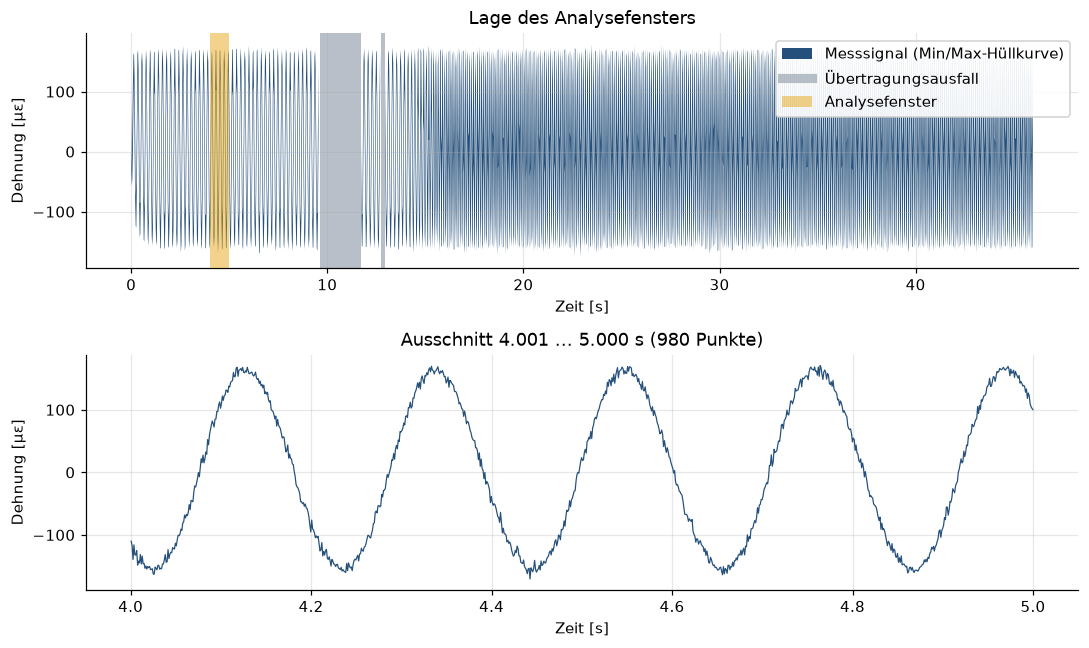

In [9]:
def select_window(frame: pd.DataFrame, t_start=None, t_end=None) -> pd.DataFrame:
    """Analyseabschnitt ausschneiden; None bedeutet 'bis zum Rand des Datensatzes'."""
    t0 = frame["t"].iloc[0] if t_start is None else t_start
    t1 = frame["t"].iloc[-1] if t_end is None else t_end
    if t1 <= t0:
        raise ValueError(f"Leeres Fenster: t_start={t0} >= t_end={t1}")
    window = frame[(frame["t"] >= t0) & (frame["t"] <= t1)].reset_index(drop=True)
    if len(window) < 4:
        raise ValueError(f"Fenster {t0}…{t1} s enthält nur {len(window)} Punkte. Grenzen prüfen.")
    return window


def plot_window_selection(frame: pd.DataFrame, window: pd.DataFrame, info: ImportInfo):
    """Zwei Panels: oben die Lage des Fensters im Gesamtverlauf, unten das Fenster selbst."""
    fig, (overview_ax, zoom_ax) = plt.subplots(2, 1, figsize=(10, 6))
    span = (float(window["t"].iloc[0]), float(window["t"].iloc[-1]))
    plot_signal(frame, info, window=span, title="Lage des Analysefensters", ax=overview_ax)
    zoom_ax.plot(window["t"], window["y"], lw=0.8, color=COLOR_SIGNAL)
    zoom_ax.set(xlabel="Zeit [s]", ylabel=f"{info.label} [{info.unit}]",
                title=f"Ausschnitt {span[0]:.3f} … {span[1]:.3f} s ({len(window)} Punkte)")
    fig.tight_layout()
    return fig


segment = select_window(data, cfg.t_start, cfg.t_end)
span = (float(segment["t"].iloc[0]), float(segment["t"].iloc[-1]))
print(f"Analysefenster: {span[0]:.3f} … {span[1]:.3f} s  "
      f"({len(segment)} Punkte, {span[1]-span[0]:.3f} s)")

fig_window = plot_window_selection(data, segment, info)
plt.show()

## 6 Signalanalyse

Die Auswertung besteht aus vier Bausteinen, die aufeinander aufbauen:

1. **Gleichmäßiges Zeitraster** – FFT und Filter setzen konstante Abtastung voraus.
   Nach der Zeitachsen-Rekonstruktion aus Abschnitt 2 ist die Interpolation nahezu wirkungslos;
   sie bleibt als Absicherung für Dateien ohne Blockstruktur.
2. **Amplitudenspektrum** – liefert das grobe Maximum als Startwert.
3. **Harmonischen-Fit** – verfeinert $f_0$ und liefert Amplituden, Offset und Drift
   unabhängig vom FFT-Raster.
4. **Signalqualität** – Rauschen, SNR, Ausreißer und die Stationaritätsprüfung.

### Zwei Rauschmaße – und warum beide gebraucht werden

| Maß | Bedeutung | Grenze |
|---|---|---|
| **Fit-Residuum** | alles, was das Modell nicht erklärt | enthält auch *Modellfehler*: ändert sich die Drehzahl im Fenster, wächst das Residuum, obwohl die Messkette nicht schlechter wird |
| **spektrale Rauschdichte** | mittlere Leistungsdichte *abseits* von DC und Harmonischen, hochgerechnet auf die Bandbreite $f_s/2$ | schmalbandige Störungen dicht an $f_0$ werden mit ausgeblendet |

Deshalb werden beide ausgewiesen. Liegt das Residuum deutlich über dem spektralen Pegel,
ist das ein Hinweis auf ein **nicht stationäres Fenster** – genau dafür ist die
Frequenzstreuung (`STATIONARITY_TOL`) die direkte Prüfgröße.

In [10]:
# ===========================================================================
#  6.1  Datenstrukturen der Analyse
# ===========================================================================
class Quantity(NamedTuple):
    """Ein Zahlenwert mit Einheit und optionaler Anmerkung.

    Trennt den *Wert* von seiner *Darstellung*: Ausgabe, CSV- und PDF-Export
    formatieren über dieselbe Struktur, statt Einheiten aus Schlüsseltexten zu raten.
    """
    value: float | None
    unit: str = ""
    note: str = ""


@dataclass(frozen=True)
class Spectrum:
    """Einseitiges Amplitudenspektrum."""
    freq: np.ndarray
    amp: np.ndarray
    resolution: float       # Frequenzauflösung 1/T [Hz]
    fs: float               # Abtastrate [Hz]


@dataclass(frozen=True)
class HarmonicFit:
    """Ergebnis des Least-Squares-Fits von Offset, Drift und K Harmonischen."""
    f0: float
    amplitudes: np.ndarray      # A_1 … A_K
    phases: np.ndarray          # rad
    offset: float
    drift: float                # Einheit/s
    model: np.ndarray
    residual: np.ndarray

    @property
    def amplitude(self) -> float:
        """Amplitude der Grundwelle - die physikalisch gesuchte Größe."""
        return float(self.amplitudes[0])

    @property
    def thd(self) -> float:
        """Klirrfaktor: Oberwellen-Energie bezogen auf die Grundwelle."""
        return float(np.sqrt(np.sum(self.amplitudes[1:] ** 2)) / self.amplitudes[0])


@dataclass(frozen=True)
class AnalysisResult:
    """Vollständiges Ergebnis eines Analysefensters."""
    window: tuple[float, float]
    n_samples: int
    fs: float
    spectrum: Spectrum
    fit: HarmonicFit
    groups: dict[str, dict[str, Quantity]]
    freq_spread: float | None       # relative Frequenzstreuung im Fenster, None = nicht prüfbar

    @property
    def f0(self) -> float:
        return self.fit.f0

    @property
    def amplitude(self) -> float:
        return self.fit.amplitude

    @property
    def rpm(self) -> float:
        return float(self.groups["Hauptkenngrößen"]["Drehzahl"].value)

    @property
    def is_stationary(self) -> bool | None:
        """None = zu wenige Perioden im Fenster, um die Frage zu beantworten."""
        return None if self.freq_spread is None else self.freq_spread <= STATIONARITY_TOL

In [11]:
# ===========================================================================
#  6.2  Spektrum und Harmonischen-Fit
# ===========================================================================
def resample_uniform(t: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """Auf ein gleichmäßiges Raster im Median-Abtastintervall interpolieren.

    FFT und IIR-Filter setzen konstante Schrittweite voraus; bei Lücken oder Jitter wäre
    das Spektrum sonst schlicht falsch. Ohne Lücken ist die Interpolation identitätsnah.
    """
    dt = float(np.median(np.diff(t)))
    t_uniform = np.arange(t[0], t[-1], dt)
    return t_uniform, np.interp(t_uniform, t, y), dt


def amplitude_spectrum(t: np.ndarray, y: np.ndarray) -> Spectrum:
    """Einseitiges Amplitudenspektrum mit Hann-Fenster.

    Skalierung 2/Σw macht die Linienhöhe zur echten Sinus-Amplitude.
    Vorher wird linear trendbereinigt, damit Offset und Drift nicht in die tiefen Bins lecken.
    """
    t_uniform, y_uniform, dt = resample_uniform(t, y)
    y_detrended = spsig.detrend(y_uniform, type="linear")
    window = spsig.windows.hann(len(y_detrended))
    amp = 2.0 * np.abs(np.fft.rfft(y_detrended * window)) / np.sum(window)
    freq = np.fft.rfftfreq(len(y_detrended), dt)
    return Spectrum(freq, amp, float(freq[1] - freq[0]), 1.0 / dt)


def coarse_frequency(spectrum: Spectrum, f_min: float = FREQ_SEARCH_MIN_HZ) -> float:
    """Größte Spektrallinie oberhalb f_min - Startwert für die Feinabstimmung."""
    band = spectrum.freq >= f_min
    if not band.any():
        raise ValueError(f"Kein Frequenzband oberhalb {f_min} Hz vorhanden.")
    return float(spectrum.freq[band][np.argmax(spectrum.amp[band])])


def fit_harmonics(t: np.ndarray, y: np.ndarray, f0: float,
                  n_harmonics: int = N_HARMONICS, fs: float | None = None) -> HarmonicFit:
    """Least-Squares-Fit  y ≈ c0 + c1·(t-t0) + Σ_k [a_k·sin(2πk f0 t) + b_k·cos(2πk f0 t)].

    Ein gemeinsames Modell für Offset, Drift, Grundwelle und Oberwellen. Vorteile gegenüber
    dem Ablesen von FFT-Bins: die Amplituden sind nicht an das Frequenzraster gebunden
    (bei 1 s Fenster wären das 1-Hz-Stufen) und das Residuum ist sauber definiert.
    Harmonische oberhalb 45 % der Abtastrate werden weggelassen - dort gäbe es nur Aliasing.
    """
    fs = fs or 1.0 / float(np.median(np.diff(t)))
    n_used = min(n_harmonics, max(1, int(0.45 * fs / f0)))
    columns = [np.ones_like(t), t - t[0]]
    for k in range(1, n_used + 1):
        columns += [np.sin(2 * np.pi * k * f0 * t), np.cos(2 * np.pi * k * f0 * t)]
    design = np.column_stack(columns)
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    model = design @ coef
    sin_coef, cos_coef = coef[2::2], coef[3::2]
    return HarmonicFit(f0=float(f0),
                       amplitudes=np.hypot(sin_coef, cos_coef),
                       phases=np.arctan2(cos_coef, sin_coef),
                       offset=float(coef[0]), drift=float(coef[1]),
                       model=model, residual=y - model)


def refine_frequency(t: np.ndarray, y: np.ndarray, f_coarse: float, resolution: float) -> float:
    """Sub-Bin-genaue Grundfrequenz: minimiert das Residuum des Harmonischen-Fits.

    Nötig, weil die FFT-Auflösung 1/T beträgt - bei einem 1-s-Fenster also 1 Hz, während
    die Drehfrequenz auf besser als 0,01 Hz bestimmbar ist.
    """
    band = REFINE_BAND_BINS * resolution
    grid = np.linspace(max(f_coarse - band, 1e-9), f_coarse + band, REFINE_GRID)
    error = [float(np.mean(fit_harmonics(t, y, f).residual ** 2)) for f in grid]
    return float(grid[int(np.argmin(error))])


def dominant_frequency(t: np.ndarray, y: np.ndarray) -> tuple[float, Spectrum]:
    """Dominante Frequenz: grobes Maximum aus der FFT, anschließend per Fit verfeinert."""
    spectrum = amplitude_spectrum(t, y)
    return refine_frequency(t, y, coarse_frequency(spectrum), spectrum.resolution), spectrum

In [12]:
# ===========================================================================
#  6.3  Rauschen, Stationarität, Kenngrößen
# ===========================================================================
def noise_band_mask(freq: np.ndarray, f0: float, n_harmonics: int = N_HARMONICS) -> np.ndarray:
    """Frequenzbins, die weder zu DC/Drift noch zu einer Harmonischen gehören.

    Eine Definition für beide Verwendungen - Rauschkennzahl und Rauschteppich im Diagramm.
    """
    mask = freq > NOISE_EXCLUDE_DC_REL * f0
    exclude = max(NOISE_EXCLUDE_BINS * float(freq[1] - freq[0]), NOISE_EXCLUDE_REL * f0)
    for k in range(1, n_harmonics + 1):
        mask &= np.abs(freq - k * f0) > exclude
    return mask


def noise_floor_rms(t: np.ndarray, y: np.ndarray, f0: float,
                    n_harmonics: int = N_HARMONICS) -> float:
    """Breitbandiger Rauschpegel aus der Leistungsdichte abseits von DC und Harmonischen.

    Die mittlere Leistungsdichte der Rauschbins, hochgerechnet auf die volle Bandbreite fs/2,
    ergibt die Rauschleistung. Der Mittelwert (nicht der Median) wird verwendet, weil das
    Rauschen hier nicht weiß ist: zwischen 20 und 100 Hz liegt spürbar mehr Leistung als im
    oberen Band, und ein Median würde diese Färbung wegmitteln.

    Der Wert ist von der Fensterlänge unabhängig - anders als die Streuung des Fit-Residuums,
    die bei wandernder Drehzahl den Modellfehler mitzählt. Umgekehrt sieht dieses Maß
    schmalbandige Störungen dicht an f0 nicht. Deshalb werden beide Zahlen ausgewiesen.
    """
    t_uniform, y_uniform, dt = resample_uniform(t, y)
    freq, psd = spsig.periodogram(y_uniform, fs=1.0 / dt, window="hann",
                                  detrend="linear", scaling="density")
    mask = noise_band_mask(freq, f0, n_harmonics)
    if not mask.any():
        return float("nan")
    return float(np.sqrt(np.mean(psd[mask]) * (0.5 / dt)))


def frequency_stability(t: np.ndarray, y: np.ndarray, f0: float) -> float | None:
    """Relative Streuung der Drehfrequenz über gleich lange Teilfenster.

    Direkte Prüfung der Annahme 'stationärer Betriebspunkt'. Zu kurze Fenster lassen sich
    nicht sinnvoll teilen (jedes Teilstück braucht mindestens MIN_PERIODS_PER_PART Perioden)
    - dann wird None zurückgegeben statt eines Scheinergebnisses.
    """
    n_parts = int(min(MAX_STATIONARITY_PARTS, (t[-1] - t[0]) * f0 // MIN_PERIODS_PER_PART))
    if n_parts < 2:
        return None
    edges = np.linspace(t[0], t[-1], n_parts + 1)
    freqs = []
    for start, end in zip(edges[:-1], edges[1:]):
        part = (t >= start) & (t <= end)
        freqs.append(dominant_frequency(t[part], y[part])[0])
    freqs = np.asarray(freqs)
    return float((freqs.max() - freqs.min()) / np.median(freqs))


def time_domain_metrics(t: np.ndarray, y: np.ndarray, unit: str) -> dict[str, Quantity]:
    """Kenngrößen im Zeitbereich.

    Standardabweichung und Varianz des Rohsignals fehlen bewusst: bei einer Schwingung sind
    sie kein Streuungsmaß, sondern nur die Amplitude in anderer Schreibweise (σ = A/√2).
    Das relevante Streuungsmaß ist der Rauschpegel in 'Signalqualität'.
    """
    dt = float(np.median(np.diff(t)))
    return {
        "Mittelwert (Offset)": Quantity(float(np.mean(y)), unit),
        "Median": Quantity(float(np.median(y)), unit),
        "Minimum": Quantity(float(np.min(y)), unit),
        "Maximum": Quantity(float(np.max(y)), unit),
        "Peak-to-Peak": Quantity(float(np.ptp(y)), unit),
        "Amplitude (p2p/2)": Quantity(float(np.ptp(y) / 2), unit, "inkl. Rauschspitzen"),
        "RMS": Quantity(float(np.sqrt(np.mean(y ** 2))), unit),
        "Signalenergie": Quantity(float(np.sum(y ** 2) * dt), f"{unit}²·s", "Σy²·Δt"),
    }


def quality_metrics(t, y, fit: HarmonicFit, unit: str, freq_spread: float | None) -> dict[str, Quantity]:
    """Drift, Rauschen, SNR und Ausreißer aus dem Harmonischen-Fit."""
    residual = fit.residual
    residual_rms = float(np.std(residual, ddof=1))
    floor = noise_floor_rms(t, y, fit.f0)
    signal_rms = fit.amplitude / np.sqrt(2)
    mad = float(median_abs_deviation(residual, scale="normal"))
    n_outliers = int(np.sum(np.abs(residual - np.median(residual)) > OUTLIER_MAD_K * mad)) if mad > 0 else 0

    if freq_spread is None:
        spread_value, spread_note, stationary_note = None, "nicht prüfbar: zu wenige Perioden", ""
    elif freq_spread <= STATIONARITY_TOL:
        spread_value, spread_note, stationary_note = 100 * freq_spread, "stationär", ""
    else:
        spread_value, spread_note = 100 * freq_spread, "instationär"
        stationary_note = "Fenster nicht stationär → modellbegrenzt"

    return {
        "Drift": Quantity(fit.drift, f"{unit}/s"),
        "Drift über Fenster": Quantity(fit.drift * (t[-1] - t[0]), unit),
        "Klirrfaktor THD": Quantity(100 * fit.thd, "%"),
        "Rauschen (Fit-Residuum)": Quantity(residual_rms, unit, stationary_note),
        "Rauschen (spektral)": Quantity(floor, unit, "breitbandig, abseits der Harmonischen"),
        "max. Abweichung vom Fit": Quantity(float(np.max(np.abs(residual))), unit),
        "SNR (Residuum)": Quantity(20 * np.log10(signal_rms / residual_rms) if residual_rms > 0 else np.inf,
                                   "dB", stationary_note),
        "SNR (spektral)": Quantity(20 * np.log10(signal_rms / floor) if floor > 0 else np.inf, "dB"),
        f"Ausreißer (>{OUTLIER_MAD_K:g}·MAD)": Quantity(n_outliers, ""),
        "Frequenzstreuung im Fenster": Quantity(spread_value, "%", spread_note),
    }

In [13]:
# ===========================================================================
#  6.4  Auswertung eines Fensters
# ===========================================================================
def analyse_window(window: pd.DataFrame, cfg: Config, info: ImportInfo) -> AnalysisResult:
    """Komplette Auswertung eines Analysefensters - eine Funktion, ein Ergebnisobjekt."""
    t, y = window["t"].to_numpy(), window["y"].to_numpy()
    unit = info.unit

    f0, spectrum = dominant_frequency(t, y)
    fit = fit_harmonics(t, y, f0, fs=spectrum.fs)
    spread = frequency_stability(t, y, f0)
    quality = quality_metrics(t, y, fit, unit, spread)

    # Die Hauptkenngrößen verweisen auf dieselben Quantity-Objekte - keine zweite Rechnung.
    headline = {
        "Drehfrequenz": Quantity(f0, "Hz"),
        "Drehzahl": Quantity(f0 * 60.0 / cfg.rpm_order, "1/min", f"Ordnung {cfg.rpm_order}"),
        "Amplitude (Grundwelle)": Quantity(fit.amplitude, unit),
        "Offset": Quantity(float(np.mean(y)), unit),
        "Rauschen (spektral)": quality["Rauschen (spektral)"],
        "SNR (spektral)": quality["SNR (spektral)"],
    }

    context = {
        "Datenpunkte": Quantity(len(y), ""),
        "Fensterlänge": Quantity(float(t[-1] - t[0]), "s"),
        "Perioden im Fenster": Quantity(float((t[-1] - t[0]) * f0), ""),
        "Abtastrate": Quantity(spectrum.fs, "Hz"),
        "Frequenzauflösung FFT": Quantity(spectrum.resolution, "Hz", "Fit ist davon unabhängig"),
    }

    return AnalysisResult(
        window=(float(t[0]), float(t[-1])), n_samples=len(y), fs=spectrum.fs,
        spectrum=spectrum, fit=fit, freq_spread=spread,
        groups={"Hauptkenngrößen": headline,
                "Zeitbereich": time_domain_metrics(t, y, unit),
                "Signalqualität": quality,
                "Messbedingungen": context},
    )


result = analyse_window(segment, cfg, info)
print(f"Auswertung fertig: f0 = {result.f0:.3f} Hz, "
      f"Amplitude = {result.amplitude:.1f} {info.unit}, Drehzahl = {result.rpm:.1f} 1/min")

Auswertung fertig: f0 = 4.763 Hz, Amplitude = 159.7 µε, Drehzahl = 285.8 1/min


## 7 Ergebnisse

Die Ausgabe formatiert ausschließlich `Quantity`-Objekte: Wert, Einheit und Anmerkung kommen
aus der Datenstruktur, nicht aus einer Sonderbehandlung einzelner Schlüsseltexte. Neue
Kenngrößen erscheinen dadurch automatisch korrekt formatiert, sobald sie einer Gruppe
hinzugefügt werden.

In [14]:
def format_quantity(q: Quantity, width: int = 12) -> str:
    """Einheitliche Zahlendarstellung: Wert, Einheit, optionale Anmerkung."""
    if q.value is None:
        text = f"{'n/a':>{width}}"
    elif isinstance(q.value, (int, np.integer)) or float(q.value).is_integer():
        text = f"{int(q.value):>{width}d}"
    else:
        text = f"{q.value:>{width}.4g}"
    tail = f" {q.unit}" if q.unit else ""
    return f"{text}{tail}" + (f"   ({q.note})" if q.note else "")


def print_result(result: AnalysisResult, info: ImportInfo) -> None:
    """Konsolenbericht eines Analysefensters."""
    key_width = max(len(k) for group in result.groups.values() for k in group)
    print("=" * 78)
    print(f"  KENNGRÖSSEN – {info.label} [{info.unit}] | {info.path.name}")
    print(f"  Fenster {result.window[0]:.3f} … {result.window[1]:.3f} s  "
          f"({result.n_samples} Punkte)")
    print("=" * 78)
    for title, group in result.groups.items():
        print(f"\n-- {title} --")
        for name, quantity in group.items():
            print(f"  {name:<{key_width}} : {format_quantity(quantity)}")

    print(f"\n-- Harmonische (k · f0 = {result.f0:.3f} Hz) --")
    reference = result.fit.amplitude
    for k, amp in enumerate(result.fit.amplitudes, start=1):
        rel_db = 20 * np.log10(amp / reference) if amp > 0 else -np.inf
        print(f"  {k}x = {k*result.f0:8.3f} Hz : {amp:10.4g} {info.unit}  ({rel_db:6.1f} dBc)")


print_result(result, info)

  KENNGRÖSSEN – Dehnung [µε] | dms_rot_20260723_153829.csv
  Fenster 4.001 … 5.000 s  (980 Punkte)

-- Hauptkenngrößen --
  Drehfrequenz                :        4.763 Hz
  Drehzahl                    :        285.8 1/min   (Ordnung 1)
  Amplitude (Grundwelle)      :        159.7 µε
  Offset                      :         2.26 µε
  Rauschen (spektral)         :        5.207 µε   (breitbandig, abseits der Harmonischen)
  SNR (spektral)              :        26.72 dB

-- Zeitbereich --
  Mittelwert (Offset)         :         2.26 µε
  Median                      :         3.03 µε
  Minimum                     :       -170.4 µε
  Maximum                     :        170.6 µε
  Peak-to-Peak                :          341 µε
  Amplitude (p2p/2)           :        170.5 µε   (inkl. Rauschspitzen)
  RMS                         :          115 µε
  Signalenergie               :    1.322e+04 µε²·s   (Σy²·Δt)

-- Signalqualität --
  Drift                       :       -1.356 µε/s
  Drift über Fenst

## 8 Visualisierung

Drei Abbildungen, jede mit einer eigenen Aussage:

1. **Fenster mit Modell** – passt das Sinusmodell zur Messung?
2. **Amplitudenspektrum** (logarithmisch) – wie sauber ist die Grundwelle, wie stark sind
   die Oberwellen, wo liegt der Rauschteppich?
3. **Residuum** – ist der Rest strukturloses Rauschen (gut) oder erkennbar periodisch
   (dann fehlt dem Modell etwas)?

Das Histogramm des Originalnotebooks entfällt: Bei einer Schwingung zeigt es die
Arcus-Sinus-Verteilung – eine Eigenschaft des Sinus, keine Eigenschaft der Messung.
Die Verteilung, die tatsächlich interessiert, ist die des *Residuums*, und die beurteilt
Abbildung 3 zusammen mit der Ausreißerzahl.

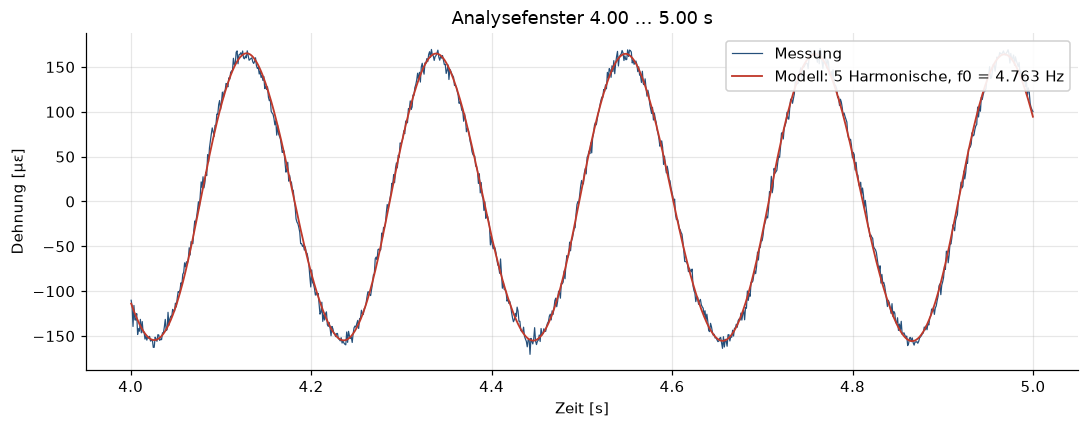

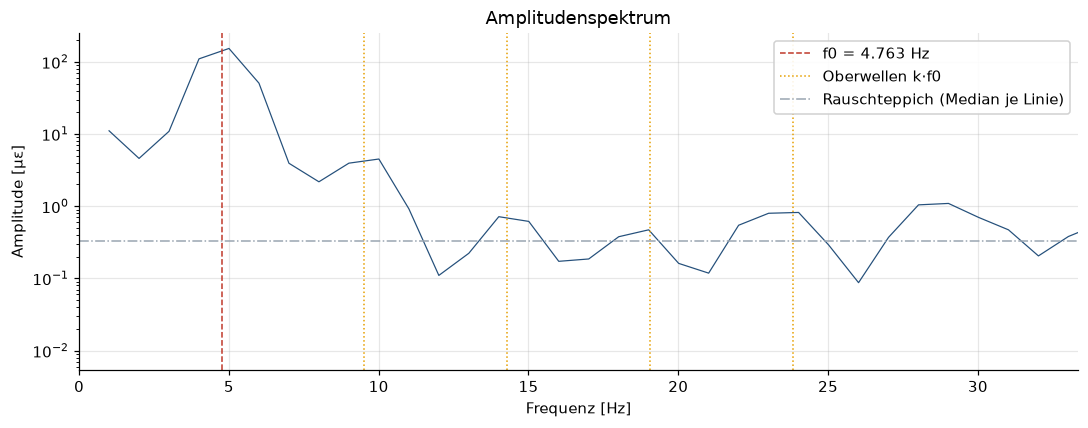

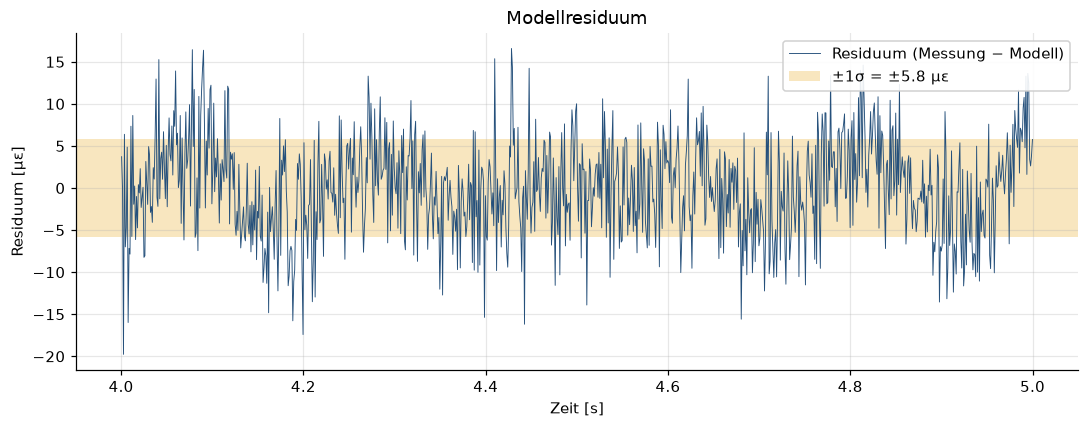

In [15]:
def plot_fit(window: pd.DataFrame, result: AnalysisResult, info: ImportInfo):
    """Messsignal und Harmonischen-Modell im Analysefenster."""
    fig, ax = plt.subplots()
    t = window["t"].to_numpy()
    ax.plot(t, window["y"].to_numpy(), lw=0.8, color=COLOR_SIGNAL, label="Messung")
    ax.plot(t, result.fit.model, lw=1.2, color=COLOR_MODEL,
            label=f"Modell: {len(result.fit.amplitudes)} Harmonische, f0 = {result.f0:.3f} Hz")
    ax.set(xlabel="Zeit [s]", ylabel=f"{info.label} [{info.unit}]",
           title=f"Analysefenster {result.window[0]:.2f} … {result.window[1]:.2f} s")
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig


def plot_spectrum(result: AnalysisResult, info: ImportInfo, n_shown_harmonics: int = N_HARMONICS):
    """Amplitudenspektrum mit markierter Grundwelle und Oberwellen (logarithmisch)."""
    fig, ax = plt.subplots()
    spectrum = result.spectrum
    ax.semilogy(spectrum.freq[1:], np.maximum(spectrum.amp[1:], LOG_PLOT_FLOOR),
                lw=0.8, color=COLOR_SIGNAL)
    ax.axvline(result.f0, color=COLOR_MODEL, ls="--", lw=1, label=f"f0 = {result.f0:.3f} Hz")
    for k in range(2, min(n_shown_harmonics, len(result.fit.amplitudes)) + 1):
        ax.axvline(k * result.f0, color=COLOR_MARK, ls=":", lw=1,
                   label="Oberwellen k·f0" if k == 2 else None)
    # Der Rauschteppich wird als Median der Rausch-Spektrallinien gezeichnet - der
    # breitbandige RMS-Wert aus der Kennzahlentabelle gehört NICHT auf diese Achse,
    # er summiert über alle Linien und läge um Größenordnungen höher.
    noise_bins = noise_band_mask(spectrum.freq, result.f0)
    if noise_bins.any():
        ax.axhline(np.median(spectrum.amp[noise_bins]), color=COLOR_MUTED, ls="-.", lw=1,
                   label="Rauschteppich (Median je Linie)")
    ax.set(xlabel="Frequenz [Hz]", ylabel=f"Amplitude [{info.unit}]",
           title="Amplitudenspektrum",
           xlim=(0, min((n_shown_harmonics + 2) * result.f0, spectrum.freq[-1])))
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig


def plot_residual(window: pd.DataFrame, result: AnalysisResult, info: ImportInfo):
    """Residuum über der Zeit mit Rauschband und markierten Ausreißern."""
    fig, ax = plt.subplots()
    t, residual = window["t"].to_numpy(), result.fit.residual
    ax.plot(t, residual, lw=0.6, color=COLOR_SIGNAL, label="Residuum (Messung − Modell)")
    sigma = float(np.std(residual, ddof=1))
    ax.axhspan(-sigma, sigma, color=COLOR_MARK, alpha=0.25, lw=0, label=f"±1σ = ±{sigma:.2g} {info.unit}")
    mad = float(median_abs_deviation(residual, scale="normal"))
    outlier = np.abs(residual - np.median(residual)) > OUTLIER_MAD_K * mad
    if outlier.any():
        ax.plot(t[outlier], residual[outlier], "o", ms=4, color=COLOR_MODEL,
                label=f"Ausreißer > {OUTLIER_MAD_K:g}·MAD ({outlier.sum()})")
    ax.set(xlabel="Zeit [s]", ylabel=f"Residuum [{info.unit}]", title="Modellresiduum")
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig


fig_fit = plot_fit(segment, result, info)
fig_spectrum = plot_spectrum(result, info)
fig_residual = plot_residual(segment, result, info)
plt.show()

## 9 Drehzahlanalyse

### Befund: unrealistische Drehzahlen bis ~58 000 1/min

Die ursprüngliche Auswertung ermittelte die Momentandrehzahl aus den **steigenden
Nulldurchgängen des mittelwertfreien Rohsignals**. Der ausgegebene Bereich lautete
„26 … 58 333 1/min“ – beide Enden sind physikalisch unmöglich.

### Ursachenanalyse

Die Extremwerte sind kein Messeffekt, sondern zwei Artefakte des Auswerteverfahrens:

**1. Rauschen am Nulldurchgang (obere Ausreißer).**
Das Signal hat rund 5 µε Rauschen. Beim Durchgang durch die Nulllinie ist die Steigung zwar
maximal, aber über einige Samples liegt das Signal trotzdem dicht an Null – dort erzeugt das
Rauschen **mehrere** Vorzeichenwechsel. Die kürzeste so entstandene „Periodendauer“ betrug
genau **ein Abtastintervall**:

$$n_\max = \frac{60}{\Delta t} \approx \frac{60}{1\ \mathrm{ms}} \approx 6\cdot 10^{4}\ \mathrm{min^{-1}}$$

Der Extremwert ist also eine Funktion der Abtastrate, nicht der Welle. Er liegt weit oberhalb
der Nyquist-Grenze $30\,f_s/\text{Ordnung}$ – ein sicheres Kennzeichen eines Artefakts.
Die Zelle unten gibt diese Grenze zum Vergleich mit aus.

**2. Ausfälle in der Übertragung (untere Ausreißer).**
Über den 2,1 s langen Paketausfall hinweg wird die Zeit zwischen zwei Nulldurchgängen als
eine einzige Periode gewertet → 60/2,3 s ≈ 26 1/min.

Ein `min_amp`-Parameter war in der alten Funktion bereits vorgesehen, aber nie ausgewertet –
die Absicht der Amplitudenprüfung war da, die Umsetzung fehlte.

### Lösung (Symptom vs. Ursache)

Nicht die Ausreißer werden weggeschnitten, sondern die Detektion wird so ausgelegt,
dass sie gar nicht erst entstehen:

| Maßnahme | Wirkung |
|---|---|
| Tiefpass bei `SPEED_LP_HARMONICS · f0` (nullphasig, Butterworth 4. Ordnung) | entfernt das Breitbandrauschen, lässt die Kurvenform intakt |
| **Schmitt-Trigger** mit ±`SPEED_HYSTERESIS_FRAC · A` | ein neuer Nulldurchgang zählt erst, nachdem das Signal die untere Schwelle unterschritten hat → Rauschen kann keine Perioden mehr erzeugen |
| Perioden über echte Ausfälle verwerfen | keine Scheinperioden über Datenlücken |
| Plausibilitätsband + robuste MAD-Grenze | letzte Sicherung, mit ausgewiesener Verwurfstatistik |

Die Verwurfstatistik wird ausgegeben: Filtern ohne Buchführung wäre Kosmetik.

In [16]:
# ===========================================================================
#  9.1  Momentandrehzahl
# ===========================================================================
@dataclass(frozen=True)
class SpeedProfile:
    """Momentandrehzahl über der Zeit samt Nachweis über verworfene Perioden."""
    t: np.ndarray
    rpm: np.ndarray
    rejected: dict[str, int]
    cutoff_hz: float
    hysteresis: float

    @property
    def n_used(self) -> int:
        return len(self.rpm)


def _rising_crossings(t: np.ndarray, y: np.ndarray, hysteresis: float) -> np.ndarray:
    """Steigende Nulldurchgänge mit Hysterese (Schmitt-Trigger), linear interpoliert.

    Ein Durchgang zählt erst, wenn das Signal vorher unter -hysteresis war. Damit ist
    ausgeschlossen, dass Rauschen um die Nulllinie zusätzliche Perioden erzeugt.
    """
    rising = np.flatnonzero((y[:-1] < 0) & (y[1:] >= 0))
    armed = np.flatnonzero((y[:-1] >= -hysteresis) & (y[1:] < -hysteresis))
    if len(rising) == 0 or len(armed) == 0:
        return np.empty(0)
    first_after_arm = np.unique(np.searchsorted(rising, armed))
    idx = rising[first_after_arm[first_after_arm < len(rising)]]
    return t[idx] + (t[idx + 1] - t[idx]) * (-y[idx]) / (y[idx + 1] - y[idx])


def instantaneous_speed(frame: pd.DataFrame, info: ImportInfo, order: int = 1) -> SpeedProfile:
    """Momentandrehzahl aus gefilterten Nulldurchgängen mit Hysterese und Ausreißerprüfung."""
    t_raw = frame["t"].to_numpy()
    t, y, dt = resample_uniform(t_raw, frame["y"].to_numpy())
    fs = 1.0 / dt
    y = spsig.detrend(y, type="linear")

    # Grobe Grundfrequenz des gesamten Datensatzes: legt Grenzfrequenz und Hysterese fest.
    f0 = coarse_frequency(amplitude_spectrum(t_raw, frame["y"].to_numpy()))
    cutoff = min(SPEED_LP_HARMONICS * f0, SPEED_LP_MAX_NYQUIST * fs)
    b, a = spsig.butter(SPEED_FILTER_ORDER, cutoff / (fs / 2), "low")
    y_filtered = spsig.filtfilt(b, a, y)

    amplitude = np.sqrt(2) * float(np.std(y_filtered))      # RMS -> Amplitude eines Sinus
    hysteresis = SPEED_HYSTERESIS_FRAC * amplitude
    crossings = _rising_crossings(t, y_filtered, hysteresis)
    if len(crossings) < 3:
        return SpeedProfile(np.empty(0), np.empty(0), {"zu wenige Nulldurchgänge": 1},
                            cutoff, hysteresis)

    periods = np.diff(crossings)
    centers = crossings[:-1] + periods / 2
    rpm = 60.0 / periods / order
    keep = np.ones(len(rpm), bool)
    rejected: dict[str, int] = {}

    # 1) Perioden, die über einen echten Übertragungsausfall laufen
    spans_gap = np.zeros(len(rpm), bool)
    for start, end in dropout_spans(t_raw, info):
        spans_gap |= (crossings[:-1] < end) & (crossings[1:] > start)
    rejected["über Ausfall"] = int(spans_gap.sum())
    keep &= ~spans_gap

    # 2) Plausibilitätsband um die mittlere Drehfrequenz
    rpm_expected = 60.0 * f0 / order
    implausible = keep & ((rpm > SPEED_PLAUSIBLE_FACTOR * rpm_expected) |
                          (rpm < rpm_expected / SPEED_PLAUSIBLE_FACTOR))
    rejected["unplausibel"] = int(implausible.sum())
    keep &= ~implausible

    # 3) Ausreißer gegen den LOKALEN Median: ein Drehzahlwechsel ist kein Ausreißer,
    #    ein einzelner Sprung zwischen zwei Nachbarperioden schon.
    if keep.sum() > SPEED_MEDIAN_WINDOW:
        deviation = periods - median_filter(periods, size=SPEED_MEDIAN_WINDOW, mode="nearest")
        mad = float(median_abs_deviation(deviation[keep], scale="normal"))
        if mad > 0:
            far = keep & (np.abs(deviation) > SPEED_OUTLIER_MAD_K * mad)
            rejected["lokale Ausreißer"] = int(far.sum())
            keep &= ~far
    return SpeedProfile(centers[keep], rpm[keep], rejected, cutoff, hysteresis)


def naive_speed(frame: pd.DataFrame, order: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Verfahren der Erstfassung: Nulldurchgänge des ungefilterten Rohsignals.

    Bleibt als Vergleichsmaßstab erhalten - er macht sichtbar, wie groß der Unterschied ist
    und dass die Extremwerte am Verfahren lagen, nicht an der Messung.
    """
    t, y = frame["t"].to_numpy(), frame["y"].to_numpy()
    centered = y - np.median(y)
    idx = np.flatnonzero((centered[:-1] < 0) & (centered[1:] >= 0))
    if len(idx) < 3:
        return np.empty(0), np.empty(0)
    crossings = t[idx] + (t[idx + 1] - t[idx]) * (-centered[idx]) / (centered[idx + 1] - centered[idx])
    periods = np.diff(crossings)
    return crossings[:-1] + periods / 2, 60.0 / periods / order


speed = instantaneous_speed(data, info, cfg.rpm_order)
t_naive, rpm_naive = naive_speed(data, cfg.rpm_order)

print("=== Drehzahlermittlung: Rohsignal vs. robustes Verfahren ===")
if speed.n_used < 2:
    print("  Kein periodisches Signal erkennbar - die Drehzahlauswertung entfällt.")
else:
    print(f"  Tiefpass            : {speed.cutoff_hz:.1f} Hz   Hysterese: "
          f"±{speed.hysteresis:.1f} {info.unit}")
    print(f"  Perioden erkannt    : {len(rpm_naive)} (roh) -> {speed.n_used} (robust)")
    for reason, count in speed.rejected.items():
        print(f"    verworfen, {reason:<18}: {count}")
    if len(rpm_naive):
        print(f"  Drehzahl roh        : {rpm_naive.min():9.1f} … {rpm_naive.max():9.1f} 1/min")
    print(f"  Drehzahl robust     : {speed.rpm.min():9.1f} … {speed.rpm.max():9.1f} 1/min")
    print(f"  Nyquist-Grenze      : {30*info.timeline.rate_true/cfg.rpm_order:9.0f} 1/min "
          f"(alles darüber ist zwangsläufig ein Artefakt)")

=== Drehzahlermittlung: Rohsignal vs. robustes Verfahren ===
  Tiefpass            : 76.5 Hz   Hysterese: ±39.7 µε
  Perioden erkannt    : 394 (roh) -> 348 (robust)
    verworfen, über Ausfall      : 2
    verworfen, unplausibel       : 0
    verworfen, lokale Ausreißer  : 7
  Drehzahl roh        :      26.2 …   57152.7 1/min
  Drehzahl robust     :     261.9 …     602.1 1/min
  Nyquist-Grenze      :     29388 1/min (alles darüber ist zwangsläufig ein Artefakt)


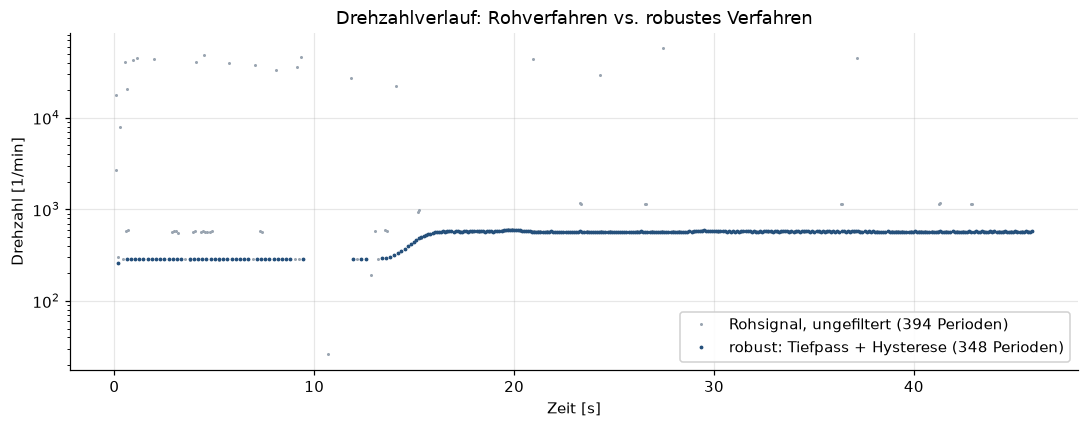

In [17]:
def plot_speed(speed: SpeedProfile, naive=None, setpoints=(),
               title="Drehzahlverlauf", log_scale=False):
    """Drehzahlverlauf; optional das Rohverfahren daneben und die Sollstufen als Band.

    Logarithmisch nur im Vergleich mit dem Rohverfahren: dessen Artefakte überspannen drei
    Dekaden, linear wäre die eigentliche Drehzahl nur eine Linie am unteren Rand.
    """
    fig, ax = plt.subplots()
    draw = ax.semilogy if log_scale else ax.plot
    if naive is not None and len(naive[1]):
        draw(naive[0], naive[1], ".", ms=2, color=COLOR_MUTED,
             label=f"Rohsignal, ungefiltert ({len(naive[1])} Perioden)")
    draw(speed.t, speed.rpm, ".", ms=3, color=COLOR_SIGNAL,
         label=f"robust: Tiefpass + Hysterese ({speed.n_used} Perioden)")
    for low, high in setpoints:
        ax.axhspan(low, high, color=COLOR_MARK, alpha=0.35, lw=0)
    if len(setpoints):
        ax.plot([], [], color=COLOR_MARK, lw=6, alpha=0.35, label="Sollstufen laut Frequenzumrichter")
    ax.set(xlabel="Zeit [s]", ylabel="Drehzahl [1/min]", title=title)
    ax.legend(loc="best")   # Punktwolken lassen keine feste Ecke frei
    fig.tight_layout()
    return fig


fig_speed = plot_speed(speed, naive=(t_naive, rpm_naive), log_scale=True,
                       title="Drehzahlverlauf: Rohverfahren vs. robustes Verfahren")
plt.show()

### 9.2 Betriebspunkte automatisch finden

Aus dem bereinigten Drehzahlverlauf lassen sich die stationären Abschnitte direkt ableiten:
ein Abschnitt wächst, solange die nächste Periode innerhalb von `SEGMENT_TOL` um den
bisherigen Median liegt. Hochläufe brechen den Abschnitt ab, Ausfälle trennen ihn.

Damit entfallen die von Hand abgelesenen Zeitfenster der Erstfassung – die häufigste
Fehlerquelle beim Auswerten einer neuen Messreihe. Eine manuelle Vorgabe bleibt über
`OPERATING_POINTS` möglich.

=== Erkannte stationäre Abschnitte ===
 Betriebspunkt  t_start [s]  t_end [s]  Drehzahl [1/min]  Perioden
BP1 ~286 1/min         0.62       9.44            285.79        39
BP2 ~575 1/min        16.24      19.47            574.76        32
BP3 ~573 1/min        20.58      45.92            572.64       243


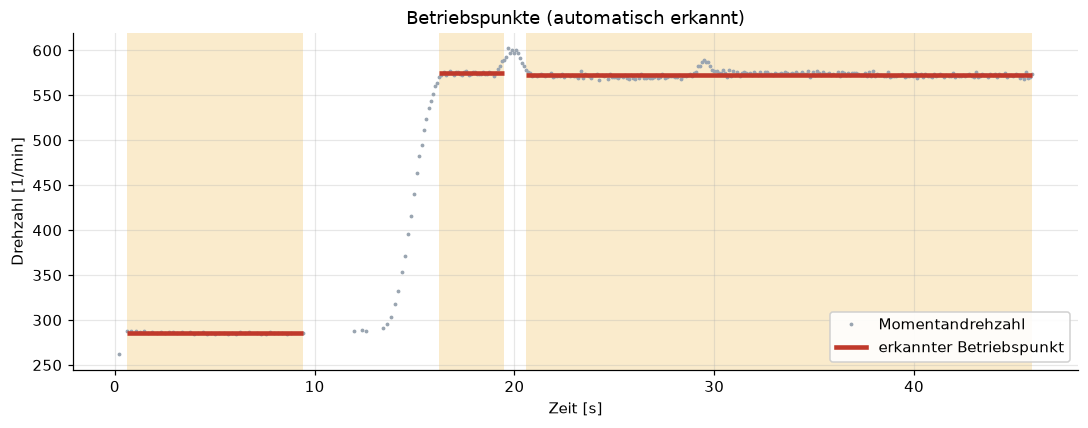

In [18]:
# ===========================================================================
#  9.2  Stationäre Abschnitte
# ===========================================================================
def find_operating_points(speed: SpeedProfile, frame: pd.DataFrame, info: ImportInfo,
                          tolerance: float = SEGMENT_TOL,
                          min_duration: float = SEGMENT_MIN_S) -> pd.DataFrame:
    """Stationäre Drehzahlabschnitte als Tabelle (Start, Ende, mittlere Drehzahl)."""
    if speed.n_used < 3:
        return pd.DataFrame(columns=["Betriebspunkt", "t_start [s]", "t_end [s]",
                                     "Drehzahl [1/min]", "Perioden"])
    breaks = {int(i) for start, end in dropout_spans(frame["t"].to_numpy(), info)
              for i in np.flatnonzero((speed.t[:-1] < end) & (speed.t[1:] > start))}

    rows, begin = [], 0
    for i in range(1, len(speed.rpm) + 1):
        if i < len(speed.rpm):
            median = float(np.median(speed.rpm[begin:i]))
            if abs(speed.rpm[i] - median) <= tolerance * median and (i - 1) not in breaks:
                continue
        if speed.t[i - 1] - speed.t[begin] >= min_duration:
            rows.append({"t_start [s]": float(speed.t[begin]), "t_end [s]": float(speed.t[i - 1]),
                         "Drehzahl [1/min]": float(np.median(speed.rpm[begin:i])),
                         "Perioden": i - begin})
        begin = i
    table = pd.DataFrame(rows)
    if not table.empty:
        table.insert(0, "Betriebspunkt", [f"BP{i+1} ~{r:.0f} 1/min"
                                          for i, r in enumerate(table["Drehzahl [1/min]"])])
    return table


# Manuelle Vorgabe: [("Name", t_start, t_end), ...]; None = automatisch erkennen
OPERATING_POINTS = None

detected = find_operating_points(speed, data, info)
print("=== Erkannte stationäre Abschnitte ===")
print(detected.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

fig_segments, ax = plt.subplots()
ax.plot(speed.t, speed.rpm, ".", ms=3, color=COLOR_MUTED, label="Momentandrehzahl")
for _, row in detected.iterrows():
    ax.hlines(row["Drehzahl [1/min]"], row["t_start [s]"], row["t_end [s]"],
              color=COLOR_MODEL, lw=3)
    ax.axvspan(row["t_start [s]"], row["t_end [s]"], color=COLOR_MARK, alpha=0.2, lw=0)
ax.plot([], [], color=COLOR_MODEL, lw=3, label="erkannter Betriebspunkt")
ax.set(xlabel="Zeit [s]", ylabel="Drehzahl [1/min]", title="Betriebspunkte (automatisch erkannt)")
ax.legend(loc="lower right")
fig_segments.tight_layout()
plt.show()

### 9.3 Auswertung je Betriebspunkt

Ein Betriebspunkt wird **nicht** mit einem einzigen Fit über seine gesamte Länge ausgewertet,
sondern in Teilfenster von `EVAL_CHUNK_PERIODS` Umdrehungen zerlegt.

**Grund.** Das Modell nimmt eine feste Grundfrequenz an. Wandert die Drehzahl über ein langes
Fenster auch nur um wenige Promille, verteilt sich die Signalenergie auf mehrere Frequenzen und
der Fit **unterschätzt die Amplitude systematisch** – im vorliegenden Datensatz um rund 10 %
über 25 s. Ein Teilfenster von etwa 20 Umdrehungen ist kurz genug, dass der Betriebspunkt darin
konstant ist, und lang genug für eine präzise Frequenzbestimmung.

**Nebennutzen.** Die Streuung der Teilfenster-Amplituden ist die *statistische* Unsicherheit der
Messung. Sie geht zusammen mit dem systematischen Budget in die Bewertung gegen die Theorie ein –
der Vergleich stützt sich damit auf beide Unsicherheitsanteile beider Seiten.

In [19]:
# ===========================================================================
#  9.3  Auswertung je Betriebspunkt
# ===========================================================================
EVAL_CHUNK_PERIODS = 20     # angestrebte Teilfensterlänge in Umdrehungen (s. Begründung oben)
MIN_CHUNK_PERIODS = 10      # kürzere Teilfenster liefern keine belastbare Frequenz mehr


def _chunk_bounds(t_start: float, t_end: float, f0: float,
                  periods: int = EVAL_CHUNK_PERIODS) -> list[tuple[float, float]]:
    """Zeitfenster in möglichst gleich lange Teilfenster von ~`periods` Umdrehungen zerlegen.

    Gerundet statt abgeschnitten: aus 31 Umdrehungen werden zwei Teilfenster à 15 statt
    eines à 31 - erst ab zwei Teilfenstern gibt es eine Streuung zu berichten.
    """
    n_periods = (t_end - t_start) * f0
    n_chunks = int(np.clip(round(n_periods / periods), 1, max(1, n_periods // MIN_CHUNK_PERIODS)))
    edges = np.linspace(t_start, t_end, n_chunks + 1)
    return list(zip(edges[:-1], edges[1:]))


def analyse_operating_point(frame: pd.DataFrame, cfg: Config, info: ImportInfo,
                            name: str, t_start: float, t_end: float):
    """Betriebspunkt über Teilfenster robust auswerten (Median) samt Streuung."""
    window = select_window(frame, t_start, t_end)
    f0_guess = coarse_frequency(amplitude_spectrum(window["t"].to_numpy(),
                                                   window["y"].to_numpy()))
    results = []
    for chunk_start, chunk_end in _chunk_bounds(t_start, t_end, f0_guess):
        try:
            results.append(analyse_window(select_window(frame, chunk_start, chunk_end), cfg, info))
        except ValueError as error:
            print(f"[{name}] Teilfenster {chunk_start:.2f}…{chunk_end:.2f} s übersprungen: {error}")
    if not results:
        return None, []

    def median_of(group: str, key: str) -> float:
        return float(np.median([r.groups[group][key].value for r in results]))

    amplitudes = np.array([r.amplitude for r in results])
    scatter = (float(np.std(amplitudes, ddof=1) / np.median(amplitudes) * 100)
               if len(amplitudes) > 1 else float("nan"))
    n_stationary = sum(r.is_stationary is not False for r in results)
    row = {
        "Betriebspunkt": name,
        "t_start [s]": float(t_start), "t_end [s]": float(t_end),
        "Teilfenster": len(results),
        "Drehfrequenz [Hz]": float(np.median([r.f0 for r in results])),
        "Drehzahl [1/min]": float(np.median([r.rpm for r in results])),
        f"Amplitude [{info.unit}]": float(np.median(amplitudes)),
        "Streuung [%]": scatter,
        f"Offset [{info.unit}]": median_of("Hauptkenngrößen", "Offset"),
        f"Rauschen [{info.unit}]": median_of("Signalqualität", "Rauschen (spektral)"),
        "SNR [dB]": median_of("Signalqualität", "SNR (spektral)"),
        "THD [%]": median_of("Signalqualität", "Klirrfaktor THD"),
        "stationär": f"{n_stationary}/{len(results)}",
    }
    return row, results


def evaluate_windows(frame: pd.DataFrame, cfg: Config, info: ImportInfo,
                     windows) -> tuple[pd.DataFrame, list[AnalysisResult]]:
    """Mehrere Betriebspunkte mit derselben Analysefunktion auswerten.

    Kein Sonderweg für den Mehrfenster-Fall: identische Rechnung wie in Abschnitt 6,
    nur über eine Schleife. Werte werden über die typisierten Felder von AnalysisResult
    abgegriffen, nicht über Beschriftungstexte.
    """
    rows, results = [], []
    for name, t_start, t_end in windows:
        try:
            row, chunk_results = analyse_operating_point(frame, cfg, info, name, t_start, t_end)
        except ValueError as error:
            print(f"[{name}] übersprungen: {error}")
            continue
        if row is not None:
            rows.append(row)
            results.extend(chunk_results)
    return pd.DataFrame(rows), results


windows = OPERATING_POINTS or [(row["Betriebspunkt"], row["t_start [s]"], row["t_end [s]"])
                               for _, row in detected.iterrows()]
operating_points, operating_results = evaluate_windows(data, cfg, info, windows)
print("=== Betriebspunkte im Vergleich ===")
print(operating_points.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

=== Betriebspunkte im Vergleich ===
 Betriebspunkt  t_start [s]  t_end [s]  Teilfenster  Drehfrequenz [Hz]  Drehzahl [1/min]  Amplitude [µε]  Streuung [%]  Offset [µε]  Rauschen [µε]  SNR [dB]  THD [%] stationär
BP1 ~286 1/min         0.62       9.44            2               4.76            285.79          158.87          0.34         1.99           5.03     26.98     3.02       2/2
BP2 ~575 1/min        16.24      19.47            2               9.58            574.97          160.37          0.22         1.15           5.00     27.11     3.19       1/2
BP3 ~573 1/min        20.58      45.92           12               9.54            572.56          160.21          0.39         0.85           4.97     27.17     3.27     11/12


### Interpretation der Betriebspunkte

Bei **konstanter Last** hängt die Dehnungsamplitude nur vom Biegemoment ab, **nicht** von der
Drehzahl. Bleiben die Amplituden über die Drehzahlstufen konstant, bestätigt das sowohl die
Messkette als auch die Annahme reiner Biegung. Eine systematische Amplitudenänderung mit der
Drehzahl wäre dagegen ein Hinweis auf Fliehkraft-, Resonanz- oder Unwuchteinflüsse.

Die Spalte **stationär** ist dabei die Vorbedingung für die Beurteilung des SNR: In einem
Fenster mit wanderndem Betriebspunkt beschreibt das Fit-Residuum den Modellfehler und nicht
das Rauschen der Messkette. Genau deshalb steht in der Tabelle der spektrale Rauschpegel,
der von dieser Frage unabhängig ist.

---
# Teil 2 – Wissenschaftliche Auswertung: Theorie ↔ Experiment

## Einleitung und Zielsetzung
Ziel des Versuchs ist der **quantitative Funktionsnachweis** des drahtlosen DMS-Messsystems
an einer rotierenden Welle. Dazu wird die gemessene Dehnungsamplitude mit dem aus
Balkentheorie berechneten Erwartungswert verglichen. Nur dieser Vergleich macht aus einer
plausiblen Messung ein **validiertes** Ergebnis.

## Versuchsbeschreibung
Eine Welle aus **Aluminium 7075** wird auf einem **3-Punkt-Biegeprüfstand** über zwei
vorgespannte Federn belastet und in Rotation versetzt. Der mitrotierende DMS (Viertelbrücke,
Dreileiterschaltung) durchläuft dabei Zug- und Druckzone der Biegung; das Messsignal ist
folglich sinusförmig mit **einfacher Drehfrequenz** (Ordnung 1). Die Daten werden per
WLAN/UDP an einen PC übertragen. Die Federlängen wurden mit dem Messschieber erfasst
(rechts und links leicht unterschiedlich, daher getrennt gerechnet).

## Theoretische Grundlage
Bei reiner Biegung eines Kreisquerschnitts gilt:

$$F = k\cdot s \qquad M_b = F_\mathrm{wirk}\cdot a \qquad
W_b=\frac{\pi d^3}{32} \qquad \sigma_b=\frac{M_b}{W_b} \qquad
\varepsilon=\frac{\sigma_b}{E}$$

mit Federkonstante $k$, Federweg $s$, Hebelarm $a$, Wellendurchmesser $d$ und E-Modul $E$.
Da der DMS mitrotiert, erwartet man $\varepsilon(t)=\hat\varepsilon\sin(\Omega t)$ mit
$\Omega = 2\pi n/60$.

**Belastungsschema.** Laut Prüfstandsaufbau wirkt der angegebene Hebelarm $a=90\,$mm von der
Krafteinleitung bis zum DMS, weshalb $M_b = F_\mathrm{ges}\cdot a$ gerechnet wird
(`load_scheme="gesamtkraft"`). Das alternative Schema `"einzelkraft"` halbiert die wirksame
Kraft und damit $\hat\varepsilon$ – die Wahl entscheidet über einen Faktor 2 und wird
deshalb in der Ausgabe immer mitgerechnet und ausgewiesen.

## Unsicherheiten – beide Seiten des Vergleichs
Ein Vergleich zweier Größen ist nur so belastbar wie die *kleinere* Aussage über ihre
Unsicherheit. Deshalb wird nicht nur die Theorie, sondern auch die **Messung** mit einem
Budget hinterlegt (k-Faktor, Verstärkung, Klebewinkel, Querempfindlichkeit) und beides
quadratisch zusammengefasst.

In [20]:
# ===========================================================================
#  VERSUCHSPARAMETER  –  zentrale Datenhaltung
# ===========================================================================
@dataclass(frozen=True)
class Experiment:
    """Randbedingungen des Versuchs an EINER Stelle.

    Quelle: Versuchsprotokoll zum Prüfstandsversuch (Federlängen per Messschieber,
    Übertragungsstatistik aus dem Log des UDP-Servers). Die Unsicherheiten sind
    begründete Schätzwerte; sie gehen vollständig in das Budget weiter unten ein.
    """
    # --- Federn / Krafteinleitung ---
    spring_free_length_mm: float = 32.22      # ungespannte Ausgangslänge
    spring_length_right_mm: float = 28.98     # gespannte Länge rechts
    spring_length_left_mm: float = 29.03      # gespannte Länge links
    spring_rate_N_per_mm: float = 12.729
    lever_arm_mm: float = 90.0                # Krafteinleitung <-> DMS

    # --- Geometrie / Werkstoff ---
    shaft_diameter_mm: float = 19.46          # Vollkreisquerschnitt
    material: str = "Aluminium 7075"
    youngs_modulus_N_per_mm2: float = 71700.0

    # --- Belastungsschema: "gesamtkraft" (M_b = F_ges·a) oder "einzelkraft" (F_ges/2) ---
    load_scheme: str = "gesamtkraft"

    # --- Betriebspunkte laut Frequenzumrichter ---
    speed_setpoints_rpm: tuple = ((276.0, 280.0), (569.0, 572.0))

    # --- Messkette ---
    gauge_factor: float = 2.06                # DMS-Datenblatt, muss zu pc_udp_server.py passen
    adc_sps_nominal: int = 1000               # Header-Wert; die reale Rate steht in info.timeline
    bridge: str = "Viertelbrücke, Dreileiter, ratiometrisch (3,3 V)"

    # --- Zuordnung: zu WELCHER Messung gehören diese Werte? ---
    # Federvorspannung und Übertragungsstatistik gelten je Messfahrt. Ohne diese Angabe
    # ließe sich eine andere Datei stillschweigend gegen fremde Randbedingungen rechnen.
    source_measurement: str = "dms_rot_20260723_153829.csv"

    # --- Übertragungsstatistik laut Server-Log (zur Gegenprobe mit der Zeitachse) ---
    samples_received: int = 42793
    samples_lost: int = 2278

    # --- Standardunsicherheiten der Theorie ---
    u_length_mm: float = 0.02                 # Messschieber, je Einzellänge
    u_spring_rate_rel: float = 0.01           # 1 % Federkonstante
    u_lever_arm_mm: float = 1.0
    u_diameter_mm: float = 0.05
    u_youngs_modulus_N_per_mm2: float = 1000.0  # Literaturstreuung Al 7075

    # --- Standardunsicherheiten der Messung ---
    u_gauge_factor_rel: float = 0.01          # k-Faktor-Toleranz laut DMS-Datenblatt
    u_adc_gain_rel: float = 0.005             # PGA-Verstärkung, ratiometrische Referenz
    u_transverse_rel: float = 0.01            # unkompensierte Querempfindlichkeit der Viertelbrücke
    alignment_deg: float = 5.0                # angenommene Winkelabweichung des DMS (wirkt mit cos²α)


experiment = Experiment()
print(f"Versuchsaufbau: {experiment.material}, d = {experiment.shaft_diameter_mm} mm, "
      f"Schema '{experiment.load_scheme}'")
if experiment.source_measurement != info.path.name:
    print(f"\n  ACHTUNG: Die Versuchsparameter gehören zu '{experiment.source_measurement}',\n"
          f"  ausgewertet wird aber '{info.path.name}'. Federvorspannung und Verluststatistik\n"
          f"  gelten je Messfahrt - der Theorievergleich unten ist damit NICHT gültig.\n"
          f"  Abhilfe: Experiment(...) mit den Randbedingungen dieser Messung anlegen.")

Versuchsaufbau: Aluminium 7075, d = 19.46 mm, Schema 'gesamtkraft'


In [21]:
# ===========================================================================
#  THEORETISCHE DEHNUNGSAMPLITUDE
# ===========================================================================
class TheoryResult(NamedTuple):
    """Ergebnis der Balkentheorie: der gesuchte Wert typisiert, die Rechenkette als Tabelle."""
    strain: float                    # erwartete Dehnungsamplitude [µm/m]
    steps: dict[str, Quantity]       # nachvollziehbare Zwischenschritte


def bending_theory(exp: Experiment) -> TheoryResult:
    """Erwartete Dehnungsamplitude aus der Balkentheorie, mit allen Zwischengrößen.

    Die beiden Federn werden getrennt gerechnet, weil ihre Vorspannung leicht
    unterschiedlich ist. Die Zwischenschritte sind Quantity-Objekte - dieselbe Darstellung
    wie die Messgrößen, damit Theorie und Experiment im Bericht gleich aussehen.
    """
    travel_right = exp.spring_free_length_mm - exp.spring_length_right_mm
    travel_left = exp.spring_free_length_mm - exp.spring_length_left_mm
    force_right = exp.spring_rate_N_per_mm * travel_right
    force_left = exp.spring_rate_N_per_mm * travel_left
    force_total = force_right + force_left

    schemes = {"gesamtkraft": force_total, "einzelkraft": force_total / 2}
    if exp.load_scheme not in schemes:
        raise ValueError(f"load_scheme muss in {sorted(schemes)} liegen.")
    force_effective = schemes[exp.load_scheme]

    moment = force_effective * exp.lever_arm_mm                      # Nmm
    section_modulus = np.pi * exp.shaft_diameter_mm ** 3 / 32        # mm³
    stress = moment / section_modulus                                # N/mm²
    strain = stress / exp.youngs_modulus_N_per_mm2 * 1e6             # µm/m

    other = next(name for name in schemes if name != exp.load_scheme)
    strain_other = (schemes[other] * exp.lever_arm_mm / section_modulus
                    / exp.youngs_modulus_N_per_mm2 * 1e6)

    steps = {
        "Federweg rechts s_r": Quantity(travel_right, "mm"),
        "Federweg links s_l": Quantity(travel_left, "mm"),
        "Federkraft rechts F_r": Quantity(force_right, "N", "k·s_r"),
        "Federkraft links F_l": Quantity(force_left, "N", "k·s_l"),
        "Gesamtkraft F_ges": Quantity(force_total, "N"),
        "wirksame Kraft F_wirk": Quantity(force_effective, "N", f"Schema '{exp.load_scheme}'"),
        "Biegemoment M_b": Quantity(moment, "Nmm", "F_wirk·a"),
        "Widerstandsmoment W_b": Quantity(section_modulus, "mm³", "π·d³/32"),
        "Biegespannung σ_b": Quantity(stress, "N/mm²", "M_b/W_b"),
        "Dehnungsamplitude ε̂": Quantity(strain, "µm/m", "σ_b/E"),
        f"ε̂ im Schema '{other}'": Quantity(strain_other, "µm/m", "Gegenprobe, Faktor 2"),
    }
    return TheoryResult(float(strain), steps)


def theory_uncertainty(exp: Experiment) -> tuple[float, dict[str, float]]:
    """Gauß'sche Fortpflanzung für ε = (k·s·a·32)/(π·d³·E).

    Alle Größen gehen multiplikativ ein → die relativen Unsicherheiten addieren sich
    quadratisch. d steht in dritter Potenz → sein Beitrag zählt dreifach.
    """
    travel_mean = exp.spring_free_length_mm - (exp.spring_length_right_mm + exp.spring_length_left_mm) / 2
    u_travel = np.sqrt(2) * exp.u_length_mm      # Differenz zweier Längenmessungen
    contributions = {
        "Federkonstante k": exp.u_spring_rate_rel,
        "Federweg s": u_travel / travel_mean,
        "Hebelarm a": exp.u_lever_arm_mm / exp.lever_arm_mm,
        "Durchmesser d (·3)": 3 * exp.u_diameter_mm / exp.shaft_diameter_mm,
        "E-Modul E": exp.u_youngs_modulus_N_per_mm2 / exp.youngs_modulus_N_per_mm2,
    }
    return float(np.sqrt(sum(v ** 2 for v in contributions.values()))), contributions


def measurement_uncertainty(exp: Experiment) -> tuple[float, dict[str, float]]:
    """Unsicherheitsbudget der gemessenen Amplitude.

    Der Klebewinkel wirkt einseitig (cos²α ≤ 1); aus dem Maximalfehler wird über die
    Rechteckverteilung (Division durch √3) eine Standardunsicherheit.
    """
    alignment_max = 1 - np.cos(np.radians(exp.alignment_deg)) ** 2
    contributions = {
        "k-Faktor DMS": exp.u_gauge_factor_rel,
        "Verstärkung/Referenz": exp.u_adc_gain_rel,
        "Querempfindlichkeit": exp.u_transverse_rel,
        f"Klebewinkel ±{exp.alignment_deg:g}°": alignment_max / np.sqrt(3),
    }
    return float(np.sqrt(sum(v ** 2 for v in contributions.values()))), contributions


def print_budget(title: str, u_rel: float, contributions: dict[str, float]) -> None:
    """Unsicherheitsbudget einheitlich ausgeben."""
    print(f"\n=== {title} ===")
    for name, value in contributions.items():
        print(f"  {name:<24}: {100*value:5.2f} %")
    print(f"  {'kombiniert (k=1)':<24}: {100*u_rel:5.2f} %")


theory = bending_theory(experiment)
strain_theory = theory.strain
u_theory, theory_parts = theory_uncertainty(experiment)
u_measurement, measurement_parts = measurement_uncertainty(experiment)
u_combined = float(np.hypot(u_theory, u_measurement))

print(f"=== Theoretische Berechnung (Balkentheorie, {experiment.material}) ===")
key_width = max(len(k) for k in theory.steps)
for name, quantity in theory.steps.items():
    print(f"  {name:<{key_width}} : {format_quantity(quantity)}")

print_budget("Unsicherheitsbudget Theorie", u_theory, theory_parts)
print_budget("Unsicherheitsbudget Messung", u_measurement, measurement_parts)
print(f"\n  kombiniert Theorie⊕Messung (k=1): {100*u_combined:5.2f} %")
print(f"  erweitert (k=2, ~95 %)          : {100*2*u_combined:5.2f} %  ->  "
      f"ε̂ = {strain_theory:.1f} ± {2*strain_theory*u_combined:.1f} µm/m")

=== Theoretische Berechnung (Balkentheorie, Aluminium 7075) ===
  Federweg rechts s_r        :         3.24 mm
  Federweg links s_l         :         3.19 mm
  Federkraft rechts F_r      :        41.24 N   (k·s_r)
  Federkraft links F_l       :        40.61 N   (k·s_l)
  Gesamtkraft F_ges          :        81.85 N
  wirksame Kraft F_wirk      :        81.85 N   (Schema 'gesamtkraft')
  Biegemoment M_b            :         7366 Nmm   (F_wirk·a)
  Widerstandsmoment W_b      :        723.5 mm³   (π·d³/32)
  Biegespannung σ_b          :        10.18 N/mm²   (M_b/W_b)
  Dehnungsamplitude ε̂       :          142 µm/m   (σ_b/E)
  ε̂ im Schema 'einzelkraft' :           71 µm/m   (Gegenprobe, Faktor 2)

=== Unsicherheitsbudget Theorie ===
  Federkonstante k        :  1.00 %
  Federweg s              :  0.88 %
  Hebelarm a              :  1.11 %
  Durchmesser d (·3)      :  0.77 %
  E-Modul E               :  1.39 %
  kombiniert (k=1)        :  2.36 %

=== Unsicherheitsbudget Messung ===
  k-Fak

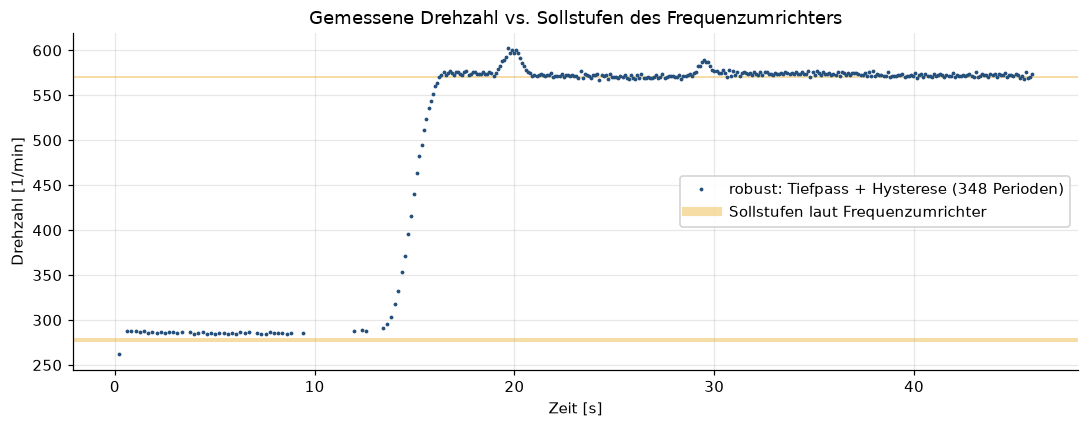

=== Theorie ↔ Experiment ===
 Betriebspunkt  Drehzahl [1/min]  Amplitude [µε]  ε_Theorie [µε]  Abweichung [µε]  Abweichung [%]  u_stat [%]  U(k=2) [%] innerhalb U(k=2)
BP1 ~286 1/min            285.79          158.87          142.00            16.87           11.88        0.24        5.67             nein
BP2 ~575 1/min            574.97          160.37          142.00            18.37           12.93        0.16        5.66             nein
BP3 ~573 1/min            572.56          160.21          142.00            18.21           12.82        0.11        5.66             nein


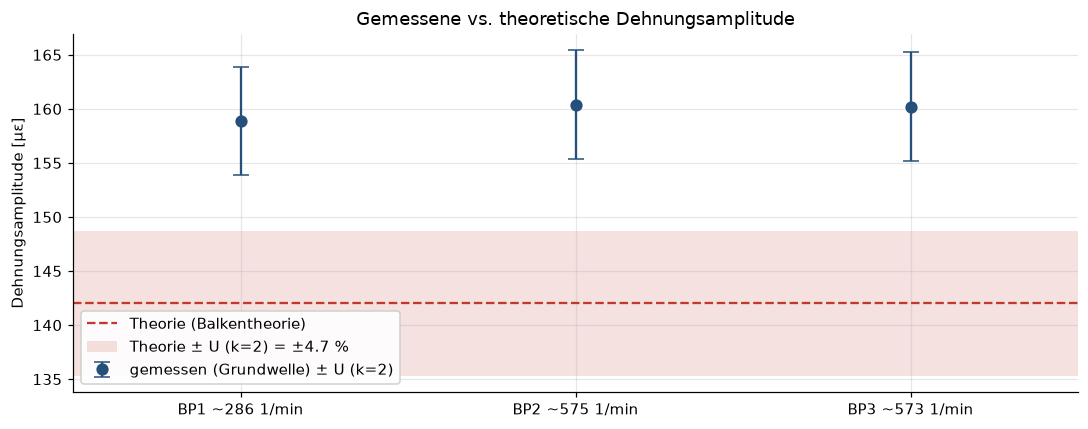

In [22]:
# ===========================================================================
#  VERGLEICH THEORIE ↔ EXPERIMENT
# ===========================================================================
def compare_with_theory(operating_points: pd.DataFrame, info: ImportInfo,
                        strain_theory: float, u_combined: float) -> pd.DataFrame:
    """Abweichung je Betriebspunkt, bewertet gegen die erweiterte Unsicherheit (k=2).

    Theorie und Messung sind direkt vergleichbar: 1 µε = 1 µm/m = 1e-6 m/m.
    """
    if operating_points.empty:
        return pd.DataFrame()
    amplitude_col = f"Amplitude [{info.unit}]"
    theory_col = f"ε_Theorie [{info.unit}]"
    table = operating_points[["Betriebspunkt", "Drehzahl [1/min]", amplitude_col]].copy()
    table[theory_col] = strain_theory
    table[f"Abweichung [{info.unit}]"] = table[amplitude_col] - strain_theory
    table["Abweichung [%]"] = 100 * table[f"Abweichung [{info.unit}]"] / strain_theory

    # statistische Unsicherheit der Messung: Streuung der Teilfenster / √n.
    # Bei nur einem Teilfenster gibt es keine Streuung -> nur der systematische Anteil zählt.
    u_statistical = (operating_points["Streuung [%]"].fillna(0.0) / 100
                     / np.sqrt(operating_points["Teilfenster"].clip(lower=1)))
    table["u_stat [%]"] = 100 * u_statistical
    table["U(k=2) [%]"] = 200 * np.hypot(u_combined, u_statistical)
    table["innerhalb U(k=2)"] = np.where(
        table["Abweichung [%]"].abs() <= table["U(k=2) [%]"], "ja", "nein")
    return table


# Gegenprobe der Drehzahl: gemessener Verlauf gegen die Sollstufen des Frequenzumrichters.
# Erst hier möglich, weil die Sollwerte zu den Versuchsrandbedingungen gehören.
fig_setpoints = plot_speed(speed, setpoints=experiment.speed_setpoints_rpm,
                           title="Gemessene Drehzahl vs. Sollstufen des Frequenzumrichters")
plt.show()

comparison = compare_with_theory(operating_points, info, strain_theory, u_combined)
print("=== Theorie ↔ Experiment ===")
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.2f}")
      if not comparison.empty else "Keine Betriebspunkte ausgewertet - Vergleich entfällt.")

def plot_theory_comparison(comparison: pd.DataFrame, info: ImportInfo, strain_theory: float,
                           u_theory: float, u_measurement: float):
    """Messpunkte mit Unsicherheitsbalken gegen das Unsicherheitsband der Theorie.

    Punkte statt Balken: eine Balkendarstellung ab der Nulllinie staucht den eigentlich
    interessanten Unterschied auf wenige Pixel. Jede Seite trägt hier ihre eigene
    Unsicherheit - ob sich Messpunkt und Theorieband überlappen, ist direkt ablesbar.
    """
    fig, ax = plt.subplots()
    x = np.arange(len(comparison))
    measured = comparison[f"Amplitude [{info.unit}]"].to_numpy()
    u_measured = np.hypot(u_measurement, comparison["u_stat [%]"].to_numpy() / 100)

    ax.axhline(strain_theory, color=COLOR_MODEL, ls="--", lw=1.5, label="Theorie (Balkentheorie)")
    ax.axhspan(strain_theory * (1 - 2*u_theory), strain_theory * (1 + 2*u_theory),
               color=COLOR_MODEL, alpha=0.15, lw=0,
               label=f"Theorie ± U (k=2) = ±{200*u_theory:.1f} %")
    ax.errorbar(x, measured, yerr=2 * measured * u_measured, fmt="o", ms=7, capsize=5,
                color=COLOR_SIGNAL, label="gemessen (Grundwelle) ± U (k=2)")
    ax.set_xticks(x, comparison["Betriebspunkt"])
    ax.set_xlim(-0.5, len(comparison) - 0.5)
    ax.set(ylabel=f"Dehnungsamplitude [{info.unit}]",
           title="Gemessene vs. theoretische Dehnungsamplitude")
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


fig_comparison = (plot_theory_comparison(comparison, info, strain_theory, u_theory, u_measurement)
                  if not comparison.empty else None)
plt.show()

## Übertragungsqualität

Zwei unabhängige Quellen beschreiben denselben Sachverhalt und werden deshalb gegeneinander
geprüft:

* die **Zählung im UDP-Server** (Sequenznummern, im Versuchsprotokoll festgehalten) und
* die **Zeitachse der CSV-Datei** selbst (Lücken zwischen den Übertragungsblöcken).

Stimmen beide überein, ist die Verlustangabe belastbar. Die Aussage „die Verluste liegen in
der Startphase" wird dabei nicht als Text übernommen, sondern aus den Zeitpunkten der
Ausfälle nachgerechnet.

In [23]:
# ===========================================================================
#  ÜBERTRAGUNGSQUALITÄT
# ===========================================================================
def transmission_quality(frame: pd.DataFrame, info: ImportInfo, exp: Experiment) -> None:
    """Verlustbilanz aus Protokoll und Zeitachse, inklusive Gegenprobe."""
    events = dropout_events(frame, info)
    lost_timeline = int(events["fehlende Samples"].sum())
    received = len(frame)
    same_measurement = exp.source_measurement == info.path.name

    print("=== Drahtlose Übertragung ===")
    print(f"  aus der Zeitachse: {received} empfangen, {lost_timeline} fehlend "
          f"({100*lost_timeline/(received+lost_timeline):.2f} %) in {len(events)} Ausfällen")
    if same_measurement:
        declared_total = exp.samples_received + exp.samples_lost
        print(f"  laut Server-Log : {exp.samples_received} empfangen, {exp.samples_lost} verloren "
              f"({100*exp.samples_lost/declared_total:.2f} %)")
        if exp.samples_lost:
            print(f"  Gegenprobe      : Abweichung der beiden Zählungen "
                  f"{100*abs(lost_timeline-exp.samples_lost)/exp.samples_lost:.1f} %")
    else:
        print(f"  (Die Protokollzahlen im Experiment-Datensatz gehören zu "
              f"'{exp.source_measurement}' und werden nicht gegengerechnet.)")
    print(f"  Abtastrate      : {info.timeline.rate_true:.1f} Hz tatsächlich "
          f"(nominell {1/info.timeline.dt_nominal:.0f} Hz, "
          f"{100*(info.timeline.rate_true*info.timeline.dt_nominal-1):+.1f} %)")

    if not events.empty:
        print("\n  Ausfälle im Detail:")
        print(events.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
        duration = float(frame["t"].iloc[-1] - frame["t"].iloc[0])
        last = float(events["t_start [s]"].iloc[-1] + events["Dauer [s]"].iloc[-1])
        share = 100 * events["fehlende Samples"].iloc[0] / max(lost_timeline, 1)
        print(f"\n  {share:.0f} % aller fehlenden Samples entfallen auf den ersten Ausfall bei "
              f"t = {events['t_start [s]'].iloc[0]:.1f} s.")
        print(f"  Nach t = {last:.2f} s bis zum Messende ({duration:.1f} s) trat kein weiterer "
              f"Ausfall auf → die Verluste sind ein Ereignis der Startphase, keine laufende Rate.")


transmission_quality(data, info, experiment)

=== Drahtlose Übertragung ===
  aus der Zeitachse: 42793 empfangen, 2278 fehlend (5.05 %) in 2 Ausfällen
  laut Server-Log : 42793 empfangen, 2278 verloren (5.05 %)
  Gegenprobe      : Abweichung der beiden Zählungen 0.0 %
  Abtastrate      : 979.6 Hz tatsächlich (nominell 1000 Hz, -2.0 %)

  Ausfälle im Detail:
 t_start [s]  Dauer [s]  fehlende Samples
       9.604      2.124              2080
      12.739      0.203               198

  91 % aller fehlenden Samples entfallen auf den ersten Ausfall bei t = 9.6 s.
  Nach t = 12.94 s bis zum Messende (46.0 s) trat kein weiterer Ausfall auf → die Verluste sind ein Ereignis der Startphase, keine laufende Rate.


## Diskussion

**Signalform.** Der DMS liefert ein sinusförmiges Signal mit einfacher Drehfrequenz – genau die
erwartete Signatur einer rotierenden Biegemessung. Der Klirrfaktor von wenigen Prozent zeigt,
dass das Signal weitgehend oberwellenfrei ist. Torsion oder Normalkraft würden ein
quasi-statisches Signal erzeugen; die Sinusform belegt somit die Biegebelastung.

**Drehzahlunabhängigkeit der Amplitude.** Siehe Vergleichstabelle: Bleibt die Amplitude über
beide Drehzahlstufen konstant, ist das ein starkes Konsistenzargument für die Messkette.

**Abweichung Theorie ↔ Experiment.** Systematische Beiträge, die eine Abweichung erklären können:

- **Belastungsschema** – der mit Abstand größte Hebel: zwischen `"gesamtkraft"` und
  `"einzelkraft"` liegt ein **Faktor 2**. Ohne geklärte Momentenverteilung am Prüfstand ist
  jede Aussage im Prozentbereich nachrangig.
- **DMS-Ausrichtung**: Eine Winkelabweichung $\alpha$ zur Wellenachse reduziert die gemessene
  Dehnung näherungsweise mit $\cos^2\alpha$ (bei 5° ≈ −1,5 %); im Messbudget berücksichtigt.
- **Querdehnungseinfluss** der Viertelbrücke (unkompensiert, wenige %).
- **Klebeschicht/Verstärkungseffekt** – reduziert die übertragene Dehnung geringfügig.
- **Wellendurchmesser** geht in **3. Potenz** ein: 0,05 mm Fehler ≈ 0,8 % in ε.
- **Reibung/Umlenkung** in der Krafteinleitung – die tatsächlich eingeleitete Kraft kann von
  der aus dem Federweg berechneten abweichen.

**Zeitbasis.** Die Auswertung deckt einen systematischen Fehler der Messkette auf: die
tatsächliche ADC-Rate liegt rund 2 % unter dem nominellen Header-Wert (Toleranz des internen
ADS1220-Oszillators). Auf die Frequenz- und Drehzahlwerte wirkt sich das **nicht** aus, weil
die Blockanfänge echte Hardware-Zeitstempel tragen und die Zeitachse daraus rekonstruiert wird.
Ohne diese Rekonstruktion erschienen jedoch mehrere hundert Pseudo-Lücken in der Statistik.
Sauberer wäre die Behebung an der Quelle: `pc_udp_server.py` sollte die Zeitstempel innerhalb
eines Pakets zwischen den echten Zeitstempeln zweier aufeinanderfolgender Pakete interpolieren,
statt die nominelle Rate zu verwenden.

**Grenzen der Aussage.** Ohne unabhängige Referenzmessung (kalibrierte Kraftmessdose,
Encoder/Tacho) ist keine Aussage zur *Richtigkeit* im metrologischen Sinn zulässig – nur zur
Konsistenz mit dem Modell. Die gemessenen Drehzahlen liegen wenige Prozent über den
Sollwerten des Frequenzumrichters; ohne Tacho lässt sich nicht entscheiden, ob das an der
Anzeige des Umrichters oder am Antrieb liegt.

## Fazit
Das drahtlose Messsystem erfasst an der rotierenden Welle ein physikalisch korrektes,
rauscharmes Biegesignal und bildet Drehzahländerungen zuverlässig ab. Der quantitative
Vergleich mit der Balkentheorie ist der entscheidende Validierungsschritt; seine Aussagekraft
steht und fällt mit der Klärung des Momentenschemas und einer unabhängigen Kraft- und
Drehzahlreferenz.

## Export

Kenngrößen als CSV, Bericht als Markdown und PDF. Die Tabelle entsteht aus denselben
`Quantity`-Objekten wie die Konsolenausgabe – es gibt keine zweite Stelle, an der Werte oder
Einheiten gepflegt werden müssten.

In [24]:
# ===========================================================================
#  EXPORT
# ===========================================================================
PDF_ROWS_PER_PAGE = 42      # passt bei 8 pt Monospace auf eine A4-Seite
A4_PORTRAIT_INCH = (8.27, 11.69)


def results_table(result: AnalysisResult, info: ImportInfo) -> pd.DataFrame:
    """Alle Kenngrößen eines Ergebnisses als flache Tabelle (für CSV/Markdown/PDF)."""
    rows = [{"Gruppe": group, "Kenngröße": name, "Wert": q.value,
             "Einheit": q.unit, "Anmerkung": q.note}
            for group, quantities in result.groups.items()
            for name, q in quantities.items() if q.value is not None]
    rows += [{"Gruppe": "Harmonische", "Kenngröße": f"Amplitude {k}·f0",
              "Wert": float(amp), "Einheit": info.unit, "Anmerkung": f"{k*result.f0:.3f} Hz"}
             for k, amp in enumerate(result.fit.amplitudes, start=1)]
    return pd.DataFrame(rows)


def _to_markdown(table: pd.DataFrame) -> str:
    """Markdown-Tabelle; 'tabulate' wird genutzt, wenn vorhanden, sonst selbst gebaut."""
    try:
        return table.to_markdown(index=False, floatfmt=".4g")
    except ImportError:
        cell = lambda v: f"{v:.4g}" if isinstance(v, float) else str(v)
        header = "| " + " | ".join(table.columns) + " |"
        rule = "| " + " | ".join("---" for _ in table.columns) + " |"
        body = ["| " + " | ".join(cell(v) for v in row) + " |" for row in table.values]
        return "\n".join([header, rule] + body)


def export_results(table: pd.DataFrame, figures: list, result: AnalysisResult,
                   info: ImportInfo, cfg: Config) -> list[Path]:
    """Kenngrößen und Abbildungen exportieren; erzeugt nur die in cfg gewünschten Formate."""
    folder = Path(cfg.output_dir)
    folder.mkdir(parents=True, exist_ok=True)
    stem = info.path.stem
    caption = (f"{info.path.name} | Fenster {result.window[0]:.3f}…{result.window[1]:.3f} s "
               f"({result.n_samples} Punkte)")
    written: list[Path] = []

    if "csv" in cfg.export_formats:
        path = folder / f"{stem}_kenngroessen.csv"
        table.to_csv(path, index=False, encoding="utf-8-sig")   # -sig: Excel erkennt UTF-8
        written.append(path)
    if "md" in cfg.export_formats:
        path = folder / f"{stem}_bericht.md"
        path.write_text(f"# Auswertungsbericht – {stem}\n\n{caption}\n\n"
                        + _to_markdown(table) + "\n", encoding="utf-8")
        written.append(path)
    if "pdf" in cfg.export_formats:
        path = folder / f"{stem}_bericht.pdf"
        text = table.to_string(index=False, float_format=lambda v: f"{v:.4g}").splitlines()
        with PdfPages(path) as pdf:
            for page, start in enumerate(range(1, len(text), PDF_ROWS_PER_PAGE)):
                figure = plt.figure(figsize=A4_PORTRAIT_INCH)
                if page == 0:
                    figure.text(0.06, 0.96, f"Auswertungsbericht – {stem}",
                                fontsize=15, weight="bold", va="top")
                    figure.text(0.06, 0.93, caption, fontsize=9, va="top")
                figure.text(0.06, 0.90 if page == 0 else 0.96,
                            "\n".join([text[0]] + text[start:start + PDF_ROWS_PER_PAGE]),
                            fontsize=8, family="monospace", va="top")
                pdf.savefig(figure)
                plt.close(figure)
            for figure in figures:
                pdf.savefig(figure)
        written.append(path)
    return written


metrics = results_table(result, info)
# Liste explizit aufgebaut statt fortgeschrieben: die Zelle ist damit beliebig oft
# wiederholbar, ohne dass sich Abbildungen doppeln.
report_figures = [fig for fig in (fig_overview, fig_window, fig_fit, fig_spectrum, fig_residual,
                                 fig_speed, fig_segments, fig_setpoints, fig_comparison)
                  if fig is not None]
for path in export_results(metrics, report_figures, result, info, cfg):
    print(f"gespeichert: {path}")
display(metrics)

gespeichert: auswertung\dms_rot_20260723_153829_kenngroessen.csv
gespeichert: auswertung\dms_rot_20260723_153829_bericht.md
gespeichert: auswertung\dms_rot_20260723_153829_bericht.pdf


,Gruppe,Kenngröße,Wert,Einheit,Anmerkung
0,Hauptkenngrößen,Drehfrequenz,4.762995,Hz,
1,Hauptkenngrößen,Drehzahl,285.779724,1/min,Ordnung 1
2,Hauptkenngrößen,Amplitude (Grundwelle),159.682756,µε,
3,Hauptkenngrößen,Offset,2.260388,µε,
4,Hauptkenngrößen,Rauschen (spektral),5.206689,µε,"breitbandig, abseits der Harmonischen"
5,Hauptkenngrößen,SNR (spektral),26.723627,dB,
6,Zeitbereich,Mittelwert (Offset),2.260388,µε,
7,Zeitbereich,Median,3.030000,µε,
8,Zeitbereich,Minimum,-170.420000,µε,
9,Zeitbereich,Maximum,170.620000,µε,


## Anhang A – Parameter-Referenz

### Anwender-Konfiguration (`Config`, Abschnitt 4)

| Parameter | Bedeutung |
|---|---|
| `t_start`, `t_end` | Analysefenster in Sekunden; `None` = bis zum Rand des Datensatzes |
| `rpm_order` | DMS-Ereignisse je Umdrehung (reine Biegung = 1, Torsionsbrücke = 2) |
| `output_dir` | Zielordner des Exports |
| `export_formats` | Teilmenge von `("csv", "md", "pdf")` |

### Versuchsparameter (`Experiment`, Teil 2)

Geometrie, Werkstoff, Federn, Belastungsschema und beide Unsicherheitsbudgets. Diese Werte
beschreiben den Versuch, nicht die Auswertung – sie gehören daher nicht in `Config`.

### Algorithmus-Konstanten (Abschnitt 1)

Verfahrensparameter mit Begründung im Quelltext. Anpassung nur nötig, wenn sich die
Messsituation grundlegend ändert – z. B. `FREQ_SEARCH_MIN_HZ` bei Drehzahlen unter 30 1/min
oder `SPEED_LP_HARMONICS` bei stark oberwellenhaltigen Signalen.

### Automatisch erkannt (keine Einstellung nötig)

Encoding, Trennzeichen, Dezimalzeichen, Kopfzeile, Zeit- und Wertespalte, Zeiteinheit,
Beschriftung, Einheit sowie Struktur und Fehler der Zeitachse.

## Anhang B – Anpassung an andere Messungen

| Situation | Vorgehen |
|---|---|
| andere Messdatei | `DATA_FILE` setzen oder auf `None` lassen (neueste Datei im Ordner) |
| Datei ohne Namensmuster in den Spalten | `read_timeseries(pfad, time_col="Spalte1", value_col="Spalte2", time_unit="s")` |
| andere Beschriftung/Einheit | `from dataclasses import replace` → `info = replace(info, label="Biegedehnung", unit="µm/m")` |
| nicht rotierendes / nicht periodisches Signal | Abschnitte 6–9 setzen eine Grundwelle voraus; Zeitbereichsgrößen bleiben gültig, Drehzahl und SNR sind dann nicht definiert |
| zusätzliche Kenngröße | in `time_domain_metrics` oder `quality_metrics` ein `Quantity` ergänzen – Ausgabe, CSV, Markdown und PDF übernehmen es automatisch |
| mehrere Dateien vergleichen | `read_timeseries` + `analyse_window` in einer Schleife; die Ergebnisse sind gewöhnliche Objekte ohne globalen Zustand |

## Anhang C – Änderungen gegenüber der Erstfassung

| Thema | vorher | jetzt |
|---|---|---|
| Dateiformat | 7 Konfigurationsfelder | automatisch erkannt |
| Zeitachse | paketweise Sprünge als „Lücken" gezählt | Blockstruktur erkannt, Zeitachse rekonstruiert, echte Ausfälle getrennt ausgewiesen |
| Abtastrate | nomineller Wert (1000 Hz) | nominell **und** tatsächlich (≈ 980 Hz) |
| Oberwellen | am nächstgelegenen FFT-Bin abgelesen (bei 1 s Fenster 1-Hz-Raster) | gemeinsamer Harmonischen-Fit, rasterunabhängig, zusätzlich THD |
| Rauschen/SNR | nur Fit-Residuum, dadurch von der Fensterlänge abhängig | zusätzlich spektraler Rauschpegel + Stationaritätsprüfung |
| Drehzahl | Nulldurchgänge des Rohsignals, bis 58 000 1/min | Tiefpass + Schmitt-Trigger + Ausfall- und Ausreißerprüfung mit Verwurfstatistik |
| Betriebspunkte | von Hand abgelesene Zeitfenster | automatisch aus dem Drehzahlverlauf, manuell überschreibbar |
| Amplitude langer Fenster | ein Fit über das ganze Fenster – bei wandernder Drehzahl bis zu 10 % zu klein | Teilfenster von ~20 Umdrehungen, Median + Streuung |
| Unsicherheit | nur Theorieseite | Theorie **und** Messung (systematisch ⊕ statistisch), quadratisch kombiniert |
| Verluststatistik | feste Zahlen im Text | aus der Zeitachse berechnet und gegen das Log geprüft |
| Ergebnisdarstellung | Einheiten aus Schlüsseltexten erraten | `Quantity(Wert, Einheit, Anmerkung)` als einzige Quelle |
| Histogramm | vorhanden | ersetzt durch Residuumsdiagramm (aussagekräftig statt dekorativ) |
| Gesamtverlauf | 40 000 Punkte als Linie = Farbblock | Min/Max-Hüllkurve mit markierten Ausfällen, dazu ein Zoom auf das Fenster |
| Theorievergleich | Balken ab Nulllinie, ohne Fehlerbalken | Messpunkte mit U(k=2) gegen das Unsicherheitsband der Theorie |